# Behavior notebook

Welcome to the behavior notebook. It's not completely up to date (e.g. there is no analysis for no block sessions), but should be enough to get started on the basics

In [105]:
import sys
from pathlib import Path

# Use __file__ if it exists (script), otherwise use the current working directory (notebook)
try:
    THIS_FILE = Path(__file__).resolve()
except NameError:
    THIS_FILE = Path.cwd() / "bhv.ipynb"

PROJECT_ROOT = THIS_FILE.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root on sys.path:", PROJECT_ROOT)


import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import cm
import random
from scipy.stats import norm
from scipy.stats import linregress


from ratcode.config.paths import PATH_STORE_PICKLES, DROPBOX_TASK_PATH, PATH_DATAFRAMES
from ratcode.common.logging import determine_experiment
from ratcode.common.colorcodes import *
from ratcode.behavior import change_point
from ratcode.behavior.pressing_rate import get_lever_press_matrix, compute_rate_aligned_cp
from ratcode.photometry.photometry import get_prediction, quantile_regression, signal2eventsnippets, find_poly, segment_and_fit_function, butter_filter, mask_jumps, make_continuous, compute_snippets_across_sessions, bootstrap_ci, categorize_presses, envelope_quantile_regression, plot_snippets
from ratcode.common.dataframe import group_and_listify
from ratcode.common.time import convert_date_bonsai, convert_timestamp
from ratcode.common.math import drop_nans_matrix, drop_nan_rows_in_matrix
from ratcode.common.colorcodes import FI_order, color_FI_blocks, rwd_order, color_rwd_blocks
from ratcode.common.plotting import remove_legend

from ratcode.init import setup

setup()

Project root on sys.path: d:\Learning Lab Dropbox\Learning Lab Team Folder\Patlab protocols\Code\Python\SF\rats_ficlickrwd


In [ ]:



#
#fig_path = r"D:\Learning Lab Dropbox\Learning Lab Team Folder\Patlab protocols\Data\FIClickRwd\analysis_bhv"

#def terciles(x):
#    if x.nunique() < 3:
#        return pd.Series([np.nan] * len(x), index=x.index)  # or assign fewer bins
#    return pd.qcut(x, 3, labels=['T1','T2','T3'], duplicates='drop')




In [ ]:
tercile_colors = ['#D95F02', '#B0B0B0', '#1B9E77']
tercile_list = ['T1', 'T2', 'T3']
tercile_rateH_colors = [cm.get_cmap('copper')(1-ii*.35) for ii in range(3)]


def _to_scalar_time(x):
    # None/NaN
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan

    # pandas/py datetime -> seconds
    if isinstance(x, (pd.Timestamp, np.datetime64)):
        return pd.to_datetime(x).value / 1e9  # ns -> s

    # 0-dim numpy numbers
    if isinstance(x, (np.floating, np.integer)):
        return float(x)

    # Python numeric
    if isinstance(x, (int, float)):
        return float(x)

    # Single-element containers (list/ndarray/tuple)
    if isinstance(x, (list, tuple, np.ndarray)):
        if len(x) == 0:
            return np.nan
        if len(x) == 1:
            return _to_scalar_time(x[0])
        # If you *expect* singletons, treat multi-length as invalid
        return np.nan

    # Strings that might be numeric or datetime
    if isinstance(x, str):
        # try numeric first
        v = pd.to_numeric(x, errors='coerce')
        if pd.notna(v):
            return float(v)
        # try datetime parse
        try:
            return pd.to_datetime(x).value / 1e9
        except Exception:
            return np.nan

    # Fallback
    return np.nan

def prepare_events(df, event_col):
    out = df.copy()
    # Fast-path: if already datetime64, convert once
    if np.issubdtype(out[event_col].dtype, np.datetime64):
        out[event_col] = pd.to_datetime(out[event_col]).astype('int64') / 1e9
    else:
        out[event_col] = out[event_col].apply(_to_scalar_time)
        out[event_col] = pd.to_numeric(out[event_col], errors='coerce')  # ensure float dtype
    return out

## imports

In [6]:
unidf = pd.read_pickle(rf'{PATH_DATAFRAMES}\unidf.pkl')
blocksdf = pd.read_pickle(rf'{PATH_DATAFRAMES}\blocksdf_july25_thesis_dataset_npx_sync.pkl')

I had the following notes on the thesis nb:

NEED TO CLEAN UP THE BLOCKSDF, i.e. discard some animals:
 -  Copper (1 session)
 - Nickel -- trained on the single condition and then ran photometry in single condition and then blocks (tests)
 - Bromine (only 8 sessions)
 - Moly has 16 sessions (could use)
for consistency, could also discard the animals that are part of single condition -- of if keeping I should mention it

In [7]:
# extra conds for considering cp
#- theta = 3 [needs rechecking]
#- more than 3 presses in the high pressing regime
#- no HL transitions [needs rechecking]
#(- no more than 1 cp)
#(- constraints on the trial duration)

unidf['count_presses_after_cp'] = unidf.query('bool_cp').presses_after_cp.apply(lambda x: len(x))
unidf['bool_cp'] = unidf.bool_cp * (unidf.count_presses_after_cp > 2)

#blocksdf['presses_after_cp_aligned_cp_ms'] = blocksdf.query('bool_cp').presses_after_cp.apply(lambda x: (x-x[0])[1:])
#blocksdf['presses_after_cp_aligned_cp_ms'] = blocksdf.presses_after_cp_aligned_cp_ms * 1000
#blocksdf['cpseries_HL_aftercp'] = blocksdf.query('bool_cp').presses_after_cp_aligned_cp_ms.apply(lambda x: change_point.simple_accepted_cp_Gallistel(x, 3, bool_onlyfirst = False, transition = 'HL'))
#blocksdf['count_HL_cp'] = blocksdf.query('bool_cp').cpseries_HL_aftercp.apply(lambda x: len(x[1])-1)
#blocksdf['cpHL'] = blocksdf.query('count_HL_cp > 0').cpseries_HL_aftercp.apply(lambda x: x[0])
#blocksdf['cpHL'] = blocksdf.cpHL + blocksdf.cp
#
#blocksdf['bool_cp'] = blocksdf.bool_cp * (blocksdf.count_HL_cp == 0)


unidf['mean_interpress'] = unidf.interpress_aftercp.apply(lambda x: x.mean() if type(x) == np.ndarray else x)
unidf['cp_corrected'] = unidf.apply(lambda x: x.cp - x.mean_interpress, axis = 1)
unidf['cp_corrected_normalised'] = unidf.cp_corrected / unidf.FI

'''
this correction is assuming the transition is done some time before being detected (lever press), sort of like a hidden state model and we only observe the events that are lever presses
to the detected cp, we subtract the mean value of the interpress distribution, for each trial
'''

unidf['lever_rel_s'] = unidf.lever_rel/1000
unidf['FI'] = unidf.FI.astype(int)

proportion_per_session = unidf.groupby('animaldate')['bool_cp'].mean().reset_index()
proportion_per_session.rename(columns={'bool_cp': 'proportion_cp'}, inplace=True)
unidf = unidf.merge(proportion_per_session, on='animaldate', how='left')

unidf['lever_aligned_corrected_cp'] = unidf.query('bool_cp').apply(lambda x: x.lever_rel_s - x.cp_corrected, axis = 1)

unidf['lever_aligned_cp'] = unidf.query('bool_cp').apply(lambda x: x.lever_rel_s - x.cp, axis = 1)
unidf['lever_aligned_cp'] = unidf.query('bool_cp').lever_aligned_cp.apply(lambda x: x[x!=0])

unidf['total_trials_within_session'] = unidf.groupby('animaldate')['trialno_withinsession'].transform('max')

unidf['latency_FI_lastpress'] = unidf.apply(lambda x: x.last_press - x.FI, axis = 1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\2016759094.py:21: RuntimeWarning: Mean of empty slice.
  unidf['mean_interpress'] = unidf.interpress_aftercp.apply(lambda x: x.mean() if type(x) == np.ndarray else x)
c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [8]:
animals_to_drop = ['Bromine', 'Copper', 'Nickel', 'Molybdenum']
blocksdf = blocksdf.query(f'animal not in {animals_to_drop}').reset_index(drop = True)

In [9]:
blocksdf['cp'] = blocksdf.apply(lambda x: x.cp if x.bool_cp else np.nan, axis = 1)

In [10]:
blocksdf['latency_FI_lastpress'] = blocksdf.apply(lambda x: x.last_press - x.FI, axis = 1)

blocksdf['lever_aligned_cp'] = blocksdf.query('bool_cp').apply(lambda x: x.lever_rel_s - x.cp, axis = 1)
blocksdf['lever_aligned_cp'] = blocksdf.query('bool_cp').lever_aligned_cp.apply(lambda x: x[x!=0])


In [11]:
blocksdf['cp_corrected'] = blocksdf.apply(lambda x: x.cp - np.mean(x.interpress_aftercp), axis = 1)
blocksdf['cp_corrected_normalised'] = blocksdf.apply(lambda x: x.cp_corrected/x.FI, axis = 1)


In [33]:
blocksdf['trialno_within_block'] = blocksdf.groupby(['animaldate', 'blockno']).cumcount() + 1

In [12]:
blocksdf['bool_new_block'] = blocksdf['blockno'] != blocksdf['blockno'].shift(1)

for key in ['FI', 'n_protocols']:
    blocksdf[f'prev_{key}'] = blocksdf.loc[blocksdf['bool_new_block'], key].groupby(blocksdf['animaldate']).shift(1)
    blocksdf[f'prev_{key}'] = blocksdf[f'prev_{key}'].ffill()


In [ ]:
sessions_to_drop = list(blocksdf.query('trial_in_session>25').animaldate.unique())
blocksdf = blocksdf.query(f'animaldate not in {sessions_to_drop}').reset_index(drop = True)

UndefinedVariableError: name 'trial_in_session' is not defined

In [15]:
blocksdf.keys()

Index(['animal', 'date', 'FI', 'click', 'trialno', 'trial_start', 'trial_end',
       'trial_duration', 'lever_abs', 'lever_rel', 'poke_abs', 'poke_rel',
       'lick_abs', 'lick_rel', 'pump_abs', 'pump_abs_stop', 'pump_rel',
       'pump_duration', 'first_press_s', 'trial_duration_s', 'blockno',
       'n_protocols', 'leverup_abs', 'leverup_rel', 'click_abs', 'click_rel',
       'bool_lever', 'count_lever', 'bool_pump', 'trialno_within_session',
       'cpseries', 'lencpseries', 'cp_logodds', 'cp_pre', 'cp_beforeFI',
       'bool_cp', 'cp', 'lever_rel_s', 'presses_after_cp', 'cp_normalised',
       'last_press', 'high_duration', 'rateH', 'session_vars', 'FI_nprots',
       'animaldate', 'first_press_beforeFI', 'pump_volume', 'pump_rwdrate',
       'pump_rwdrate_clean', 'date_mmdd', 'datetime', 'date_FI', 'interpress',
       'interpress_aftercp', 'presses_cp2FI', 'interpress_cp2FI',
       'nprots_over_FI', 'nprots_approx', 'experiment', 'FI_len', 'nprots_len',
       'bool_consider_s

In [17]:
blocksdf.blockno

0            5
1            5
2            5
3            5
4            5
          ... 
142350    7789
142351    7789
142352    7789
142353    7790
142354    7790
Name: blockno, Length: 142355, dtype: int64

## example sessions

In [18]:
unidf.query('click == False and FI == 60 and animal == "Carbon"').date.unique()

array(['220209', '220210', '220211', '220214', '220215', '220218',
       '220304', '220307', '220308', '220309', '220310', '220314',
       '220315', '220316', '220328', '220329', '220413', '220414',
       '220415', '220503', '220505'], dtype=object)

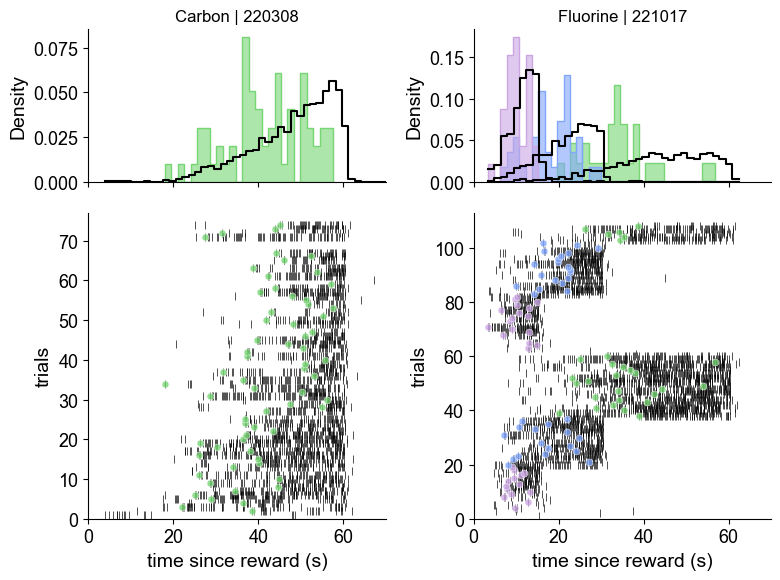

In [22]:
fig, axs = plt.subplots(2,2, figsize = (8,6), tight_layout = True, sharex='col', height_ratios=[1,2])


## example of fixed FI 30
animal = 'Carbon'
date = '220308'
egdf = unidf.query(f'animal == "{animal}" and date == "{date}" and count_lever >=1').reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,0], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = color_FI_blocks[2], fill=True,
             alpha = 0.6, binwidth=1.5)
sns.histplot(ax = axs[0,0], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False,
             binwidth = 1.5)

sns.scatterplot(ax = axs[1,0], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
sns.scatterplot(ax = axs[1,0], data = egdf, x = 'cp', y = 'trial', marker = 'o', alpha = 0.8,
                color = color_FI_blocks[2], s = 25)

axs[1,0].set_xlim(0,70)
axs[1,0].set_ylim(0,len(egdf)+3)

axs[0,0].set_title(f'{animal} | {date}', fontsize = 12)


## example of blocks, exp a
animal = 'Fluorine'
date = '221017'
egdf = blocksdf.query(f'animal == "{animal}" and date == "{date}"').reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,1], data = egdf, x = 'cp', hue = 'FI', common_norm=False, 
             stat = 'density', element = 'step', palette = color_FI_blocks, fill=True,
             alpha = 0.6, binwidth=1.5)
sns.histplot(ax = axs[0,1], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s', hue = 'FI',
             stat = 'density', element = 'step', palette = ['black']*3, fill = False, common_norm = False,
             binwidth=1.5)
#axs[0,1].axvline(30, color = 'grey', alpha = 1, ls = '--')

sns.scatterplot(ax = axs[1,1], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
for ii in range(3):
    sns.scatterplot(ax = axs[1,1], data = egdf.query(f'FI == {FI_order[ii]}'), x = 'cp', y = 'trial', marker = 'o', alpha = 0.8,
                color = color_FI_blocks[ii], s = 25)

axs[0,1].set_title(f'{animal} | {date}', fontsize = 12)

axs[1,1].set_xlim(0,70)
axs[1,1].set_ylim(0,len(egdf)+5)

for ii in range(2):
    axs[1,ii].set_xlabel('time since reward (s)')
    axs[1,ii].set_ylabel('trials')

remove_legend(axs[0,1])

figtitle = 'Example sessions fixed vs blocks'
#fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle}.png')
#fig.savefig(fr'{fig_path}\{figtitle}.pdf')

## transition point and scalar timing

Text(0.5, 0.98, 'Transition point is scalar invariant')

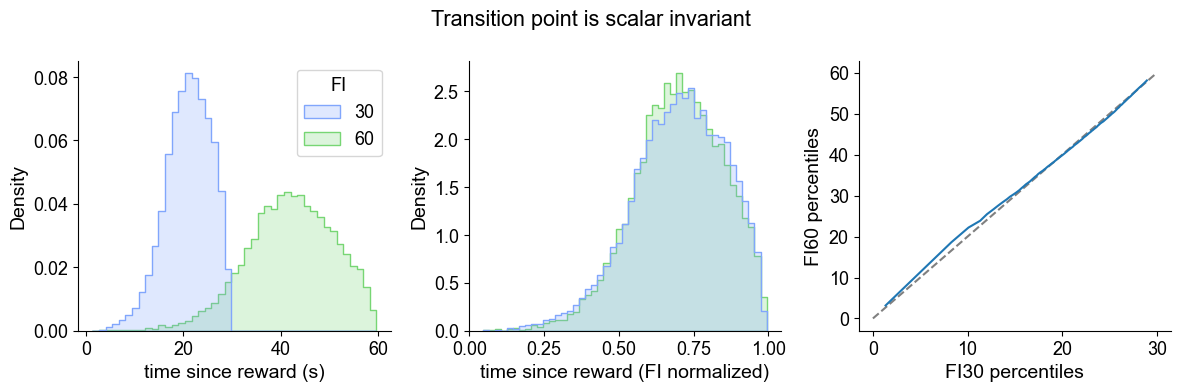

In [23]:
fig, axs = plt.subplots(1, 3, figsize = (12,4), tight_layout = True)

sns.histplot(ax = axs[0], data = unidf.query('bool_cp and click == False'), x = 'cp_corrected', hue = 'FI', palette=color_FI_blocks[1:],
             stat = 'density', common_norm=False, element='step')
sns.histplot(ax = axs[1], data = unidf.query('bool_cp and click == False'), x = 'cp_corrected_normalised', hue = 'FI', palette=color_FI_blocks[1:],
             stat = 'density', common_norm=False, element='step', binwidth=.02)

axs[0].set_xlabel('time since reward (s)')
axs[1].set_xlabel('time since reward (FI normalized)')

remove_legend(axs[1])

axs[2].plot([0,30], [0,60], color = 'grey', ls = '--')
axs[2].plot(np.quantile(unidf.query('click == False and FI == 30').cp_corrected.dropna().values, np.arange(0,1,.01)),
np.quantile(unidf.query('click == False and FI == 60').cp_corrected.dropna().values, np.arange(0,1,.01)))
axs[2].set_xlabel('FI30 percentiles')
axs[2].set_ylabel('FI60 percentiles')
#axs[2].set_xlim(0)
#axs[2].set_ylim(0)

figtitle = 'Transition point is scalar invariant'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle}.png')
#fig.savefig(fr'{fig_path}\{figtitle}.pdf')

Text(0.5, 0.98, 'Example trials pooled from sessions in fixed conditions')

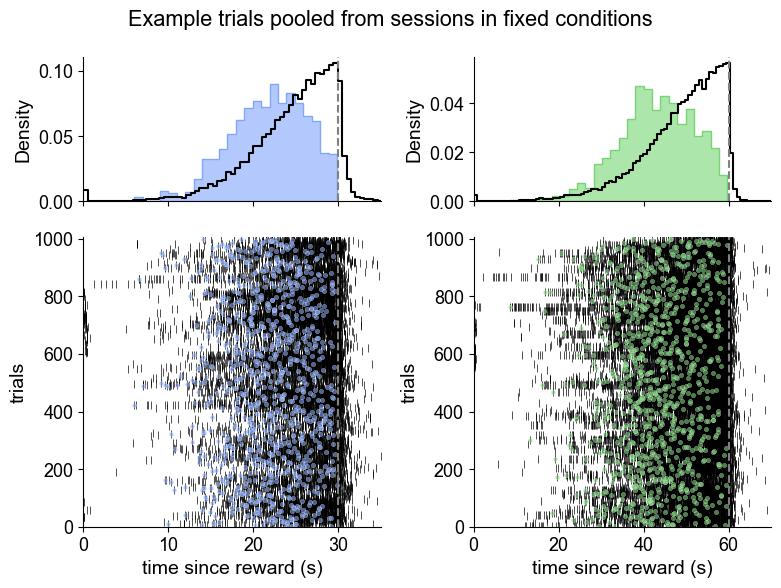

In [24]:
## cool color to contrast to black: #009E73

fig, axs = plt.subplots(2,2, figsize = (8,6), tight_layout = True, sharex='col', height_ratios=[1,2])

n_trials = 1000
# FI30 vs FI60

egdf = unidf.query(f'click == False and FI == 30 and bool_cp')
frac = n_trials/len(egdf)
egdf = egdf.sample(frac=frac, random_state=32).sort_values(by = 'trialno', ascending = True).reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,0], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = color_FI_blocks[1], fill=True,
             alpha = 0.6, binwidth=1)
sns.histplot(ax = axs[0,0], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False)
axs[0,0].axvline(30, color = 'grey', alpha = 1, ls = '--')

sns.scatterplot(ax = axs[1,0], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
sns.scatterplot(ax = axs[1,0], data = egdf, x = 'cp', y = 'trial', marker = 'o', alpha = 0.6,
                color = color_FI_blocks[1], s = 10)
axs[1,0].axvline(30, color = 'grey', alpha = 1, ls = '--')

axs[1,0].set_xlim(0,35)
axs[1,0].set_ylim(0,n_trials+5)
axs[1,0].set_xlabel('time since reward (s)')
axs[1,0].set_ylabel('trials')


## FI 60 ##
egdf = unidf.query(f'click == False and FI == 60 and bool_cp')
frac = n_trials/len(egdf)
egdf = egdf.sample(frac=frac, random_state=31).sort_values(by = 'trialno', ascending = True).reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,1], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = color_FI_blocks[2], fill=True,
             alpha = 0.6, binwidth=2)
sns.histplot(ax = axs[0,1], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False)
axs[0,1].axvline(60, color = 'grey', alpha = 1, ls = '--')

sns.scatterplot(ax = axs[1,1], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
sns.scatterplot(ax = axs[1,1], data = egdf, x = 'cp', y = 'trial', marker = 'o', alpha = 0.6,
                color = color_FI_blocks[2], s = 10)
axs[1,1].axvline(60, color = 'grey', alpha = 1, ls = '--')

axs[1,1].set_xlim(0,70)
axs[1,1].set_ylim(0,n_trials+5)
axs[1,1].set_xlabel('time since reward (s)')
axs[1,1].set_ylabel('trials')

figtitle = 'Example trials pooled from sessions in fixed conditions'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle}.png')

c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


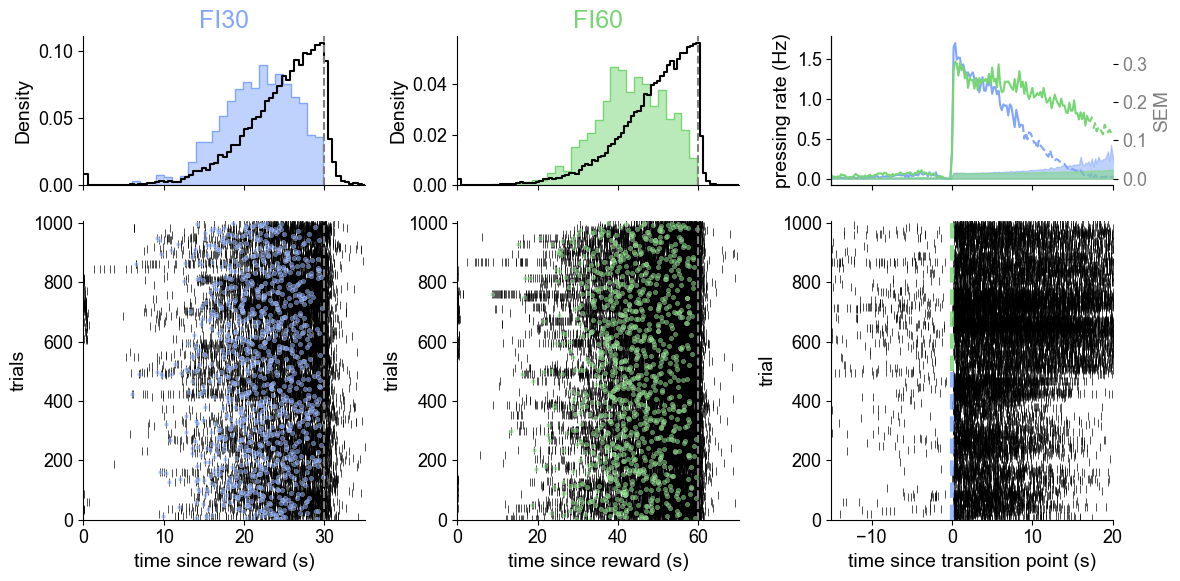

In [25]:
##### EXPANDED
## cool color to contrast to black: #009E73

fig, axs = plt.subplots(2,3, figsize = (12,6), tight_layout = True, sharex='col', height_ratios=[1,2])

n_trials = 1000

bin_width = 0.2
bins = np.arange(-15, 45 + bin_width, bin_width)


# FI30 vs FI60

egdf = unidf.query(f'click == False and FI == 30 and bool_cp')
frac = n_trials/len(egdf)
egdf = egdf.sample(frac=frac, random_state=32).sort_values(by = 'trialno', ascending = True).reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,0], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = color_FI_blocks[1], fill=True,
             alpha = 0.5, binwidth=1)
sns.histplot(ax = axs[0,0], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False)
axs[0,0].axvline(30, color = 'grey', alpha = 1, ls = '--')

sns.scatterplot(ax = axs[1,0], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
sns.scatterplot(ax = axs[1,0], data = egdf, x = 'cp', y = 'trial', marker = 'o', alpha = 0.6,
                color = color_FI_blocks[1], s = 10)
axs[1,0].axvline(30, color = 'grey', alpha = 1, ls = '--')

axs[1,0].set_xlim(0,35)
axs[1,0].set_ylim(0,n_trials+5)
axs[1,0].set_xlabel('time since reward (s)')
axs[1,0].set_ylabel('trials')

sns.scatterplot(ax = axs[1,2], data = egdf.query(f'trial < {n_trials}/2').explode('lever_aligned_cp'), x = 'lever_aligned_cp', y = 'trial',
                marker = '|', color = 'black')
lever_press_matrix = np.full((len(egdf), len(bins) - 1), np.nan)

for i, trial_data in enumerate(egdf.lever_aligned_cp):
    if isinstance(trial_data, np.ndarray):
        counts, _ = np.histogram(trial_data, bins=bins)
        lever_press_matrix[i, :len(counts)] = counts

for i in range(lever_press_matrix.shape[0]):
    last_one_index = np.where(lever_press_matrix[i] == 1)[0]
    if len(last_one_index) > 0:
        lever_press_matrix[i, last_one_index[-1] + 1:] = np.nan

#axs[1,2].set_xlim(-10,20)
#axs[1,2].set_ylim(0,n_trials+5)
axs[1,2].plot([0,0],[0,n_trials/2], color = color_FI_blocks[1], ls = '--', alpha = .8, lw = 3)

mean_rate = np.nansum(lever_press_matrix, axis = 0)/n_trials/bin_width
frac_finished_trials = np.sum(np.isnan(lever_press_matrix), axis = 0)/n_trials

SEM = np.nanstd(lever_press_matrix, axis=0) / (np.sqrt((1 - frac_finished_trials) * n_trials))

#axs[0,2].plot(bins[:-1][frac_finished_trials<1], frac_finished_trials[frac_finished_trials<1])
axs[0,2].plot(bins[:-1][frac_finished_trials<0.5], mean_rate[frac_finished_trials<0.5], color = color_FI_blocks[1])
axs[0,2].plot(bins[:-1][(frac_finished_trials>=0.5)&(frac_finished_trials<1)], mean_rate[(frac_finished_trials>=0.5)&(frac_finished_trials<1)], ls = '--', color = color_FI_blocks[1])

twin_ax = axs[0,2].twinx()
twin_ax.fill_between(bins[:-1],np.zeros(len(SEM)), SEM, color=color_FI_blocks[1], alpha = 0.5)




## FI 60 ##
egdf = unidf.query(f'click == False and FI == 60 and bool_cp')
frac = n_trials/len(egdf)
egdf = egdf.sample(frac=frac, random_state=31).sort_values(by = 'trialno', ascending = True).reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,1], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = color_FI_blocks[2], fill=True,
             alpha = 0.5, binwidth=2)
sns.histplot(ax = axs[0,1], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False)
axs[0,1].axvline(60, color = 'grey', alpha = 1, ls = '--')

sns.scatterplot(ax = axs[1,1], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
sns.scatterplot(ax = axs[1,1], data = egdf, x = 'cp', y = 'trial', marker = 'o', alpha = 0.6,
                color = color_FI_blocks[2], s = 10)
axs[1,1].axvline(60, color = 'grey', alpha = 1, ls = '--')

axs[1,1].set_xlim(0,70)
axs[1,1].set_ylim(0,n_trials+5)
axs[1,1].set_xlabel('time since reward (s)')
axs[1,1].set_ylabel('trials')



sns.scatterplot(ax = axs[1,2], data = egdf.query(f'trial > {n_trials}/2').explode('lever_aligned_cp'), x = 'lever_aligned_cp', y = 'trial',
                marker = '|', color = 'black')

lever_press_matrix = np.full((len(egdf), len(bins) - 1), np.nan)

for i, trial_data in enumerate(egdf.lever_aligned_cp):
    if isinstance(trial_data, np.ndarray):
        counts, _ = np.histogram(trial_data, bins=bins)
        lever_press_matrix[i, :len(counts)] = counts

for i in range(lever_press_matrix.shape[0]):
    last_one_index = np.where(lever_press_matrix[i] == 1)[0]
    if len(last_one_index) > 0:
        lever_press_matrix[i, last_one_index[-1] + 1:] = np.nan

axs[1,2].set_xlim(-15,20)
axs[1,2].set_ylim(0,n_trials+5)
axs[1,2].plot([0,0],[n_trials/2,n_trials], color = color_FI_blocks[2], ls = '--', alpha = .8, lw = 3)

mean_rate = np.nansum(lever_press_matrix, axis = 0)/n_trials/bin_width
frac_finished_trials = np.sum(np.isnan(lever_press_matrix), axis = 0)/n_trials
                          

SEM = np.nanstd(lever_press_matrix, axis=0) / (np.sqrt((1 - frac_finished_trials) * n_trials))

#axs[0,2].plot(bins[:-1][frac_finished_trials<1], frac_finished_trials[frac_finished_trials<1])
twin_ax.fill_between(bins[:-1],np.zeros(len(SEM)), SEM, color=color_FI_blocks[2], alpha = 0.5)

twin_ax.set_ylabel('SEM', color='grey')
twin_ax.tick_params(axis='y', labelcolor='grey')

axs[0,2].plot(bins[:-1][frac_finished_trials<0.5], mean_rate[frac_finished_trials<0.5], label = 'FI60', color = color_FI_blocks[2])
axs[0,2].plot(bins[:-1][(frac_finished_trials>=0.5)&(frac_finished_trials<1)], mean_rate[(frac_finished_trials>=0.5)&(frac_finished_trials<1)], ls = '--', color = color_FI_blocks[2])
#axs[0,2].fill_between(bins[:-1], mean_rate-SEM,mean_rate+SEM, color = 'red')


#axs[0,2].set_ylim(0)
axs[0,2].set_ylabel('pressing rate (Hz)')
axs[1,2].set_xlabel('time since transition point (s)')

#plt.legend()
axs[0,0].set_title('FI30', color = color_FI_blocks[1])
axs[0,1].set_title('FI60', color = color_FI_blocks[2])


figtitle = 'Example trials pooled from sessions in fixed conditions | aligned to last reward or transition point'
#fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.pdf')


## blocks

Text(0.5, 0.98, 'Transition point in block sessions | varying FI | all trials')

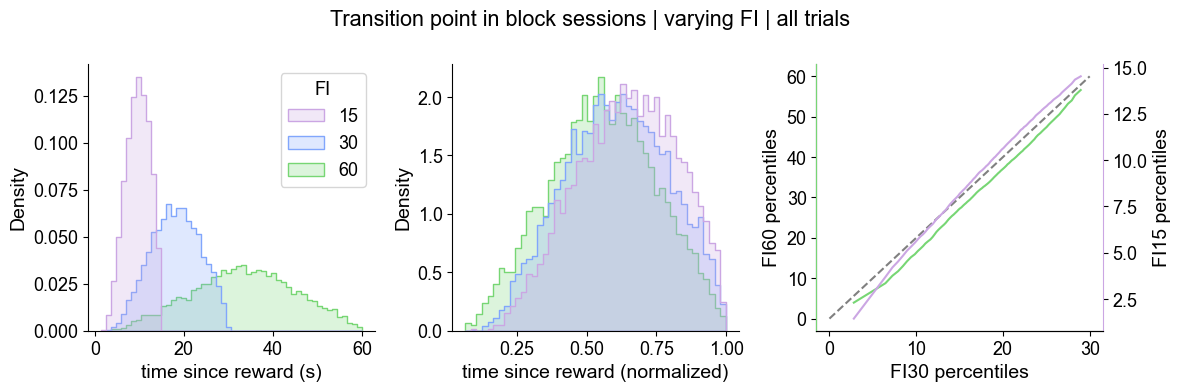

In [27]:
fig, axs = plt.subplots(1, 3, figsize = (12,4), tight_layout = True)

sns.histplot(ax = axs[0], data = blocksdf.query('bool_cp and experiment != "c" and click == False'), x = 'cp_corrected', hue = 'FI', palette=color_FI_blocks,
             stat = 'density', common_norm=False, element='step')
sns.histplot(ax = axs[1], data = blocksdf.query('bool_cp and experiment != "c" and click == False'), x = 'cp_corrected_normalised', hue = 'FI', palette=color_FI_blocks,
             stat = 'density', common_norm=False, element='step', binwidth=.02)

axs[0].set_xlabel('time since reward (s)')
axs[1].set_xlabel('time since reward (normalized)')

remove_legend(axs[1])

axs[2].plot([0,30], [0,60], color = 'grey', ls = '--')
axs[2].plot(np.quantile(blocksdf.query('click == False and experiment != "c" and FI == 30').cp_corrected.dropna().values, np.arange(0,1,.01)),
np.quantile(blocksdf.query('click == False and FI == 60').cp_corrected.dropna().values, np.arange(0,1,.01)),
color = color_FI_blocks[2])

axs2 = axs[2].twinx()
#axs2.plot([0,30], [0,15], color = 'grey', ls = '--')
axs2.plot(np.quantile(blocksdf.query('click == False and experiment != "c" and FI == 30').cp_corrected.dropna().values, np.arange(0,1,.01)),
np.quantile(blocksdf.query('click == False and experiment != "c" and FI == 15').cp_corrected.dropna().values, np.arange(0,1,.01)),
color = color_FI_blocks[0])

axs[2].set_xlabel('FI30 percentiles')
axs[2].set_ylabel('FI60 percentiles')
axs2.set_ylabel('FI15 percentiles')

#axs2.tick_params(axis='y', colors=color_FI_blocks[0])
axs2.spines['right'].set_visible(True)
axs2.spines['right'].set_color(color_FI_blocks[0])

axs2.spines['left'].set_color(color_FI_blocks[2])


#axs[2].set_xlim(0)
#axs[2].set_ylim(0)

figtitle = 'Transition point in block sessions | varying FI | all trials'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.pdf')

Text(0.5, 0.98, 'Transition point in block sessions | varying FI | steady state')

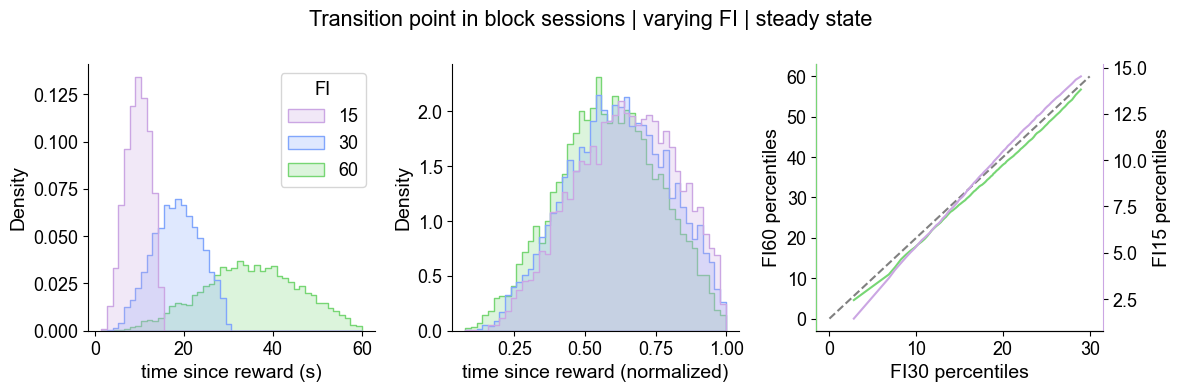

In [34]:
fig, axs = plt.subplots(1, 3, figsize = (12,4), tight_layout = True)

sns.histplot(ax = axs[0], data = blocksdf.query('bool_cp and experiment != "c" and click == False and trialno_within_block > 5'), x = 'cp_corrected', hue = 'FI', palette=color_FI_blocks,
             stat = 'density', common_norm=False, element='step')
sns.histplot(ax = axs[1], data = blocksdf.query('bool_cp and experiment != "c" and click == False and trialno_within_block > 5'), x = 'cp_corrected_normalised', hue = 'FI', palette=color_FI_blocks,
             stat = 'density', common_norm=False, element='step', binwidth=.02)

axs[0].set_xlabel('time since reward (s)')
axs[1].set_xlabel('time since reward (normalized)')

remove_legend(axs[1])

axs[2].plot([0,30], [0,60], color = 'grey', ls = '--')
axs[2].plot(np.quantile(blocksdf.query('click == False and experiment != "c" and FI == 30 and trialno_within_block > 5').cp_corrected.dropna().values, np.arange(0,1,.01)),
np.quantile(blocksdf.query('click == False and FI == 60 and trialno_within_block > 5').cp_corrected.dropna().values, np.arange(0,1,.01)),
color = color_FI_blocks[2])

axs2 = axs[2].twinx()
#axs2.plot([0,30], [0,15], color = 'grey', ls = '--')
axs2.plot(np.quantile(blocksdf.query('click == False and experiment != "c" and FI == 30 and trialno_within_block > 5').cp_corrected.dropna().values, np.arange(0,1,.01)),
np.quantile(blocksdf.query('click == False and FI == 15 and trialno_within_block > 5').cp_corrected.dropna().values, np.arange(0,1,.01)),
color = color_FI_blocks[0])

axs[2].set_xlabel('FI30 percentiles')
axs[2].set_ylabel('FI60 percentiles')
axs2.set_ylabel('FI15 percentiles')

#axs2.tick_params(axis='y', colors=color_FI_blocks[0])
axs2.spines['right'].set_visible(True)
axs2.spines['right'].set_color(color_FI_blocks[0])

axs2.spines['left'].set_color(color_FI_blocks[2])


#axs[2].set_xlim(0)
#axs[2].set_ylim(0)

figtitle = 'Transition point in block sessions | varying FI | steady state'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.pdf')

Text(0.5, 0.98, 'Adaptation to new temporal scale in block sessions | varying FI')

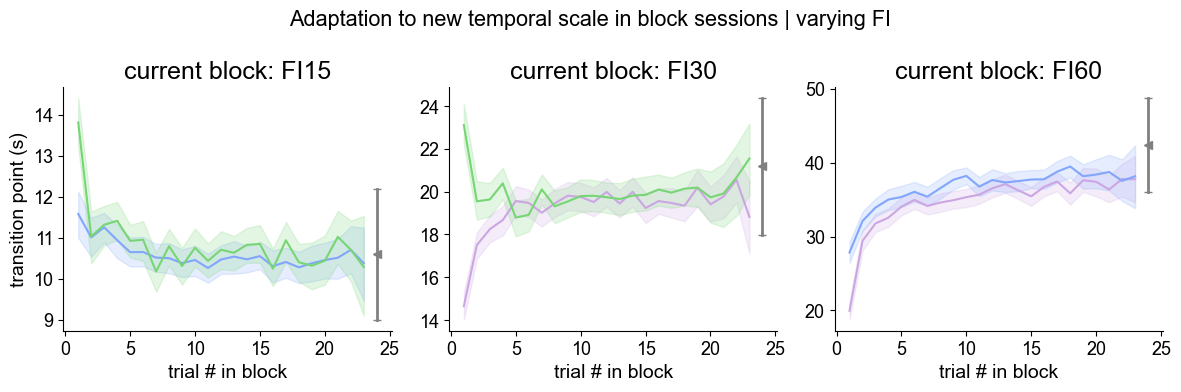

In [36]:
ref_unidf_cp_normalised = np.nanquantile(unidf.query('click == False').cp_corrected_normalised, [.25,.5,.75])

fig, axs = plt.subplots(1,3, figsize = (12,4), tight_layout = True, sharex=True)

sns.lineplot(ax = axs[0], data = blocksdf.query('click == False and experiment != "c" and prev_FI == 30 and FI == 15 and trialno_within_block <24'),
             x = 'trialno_within_block', y = 'cp', color = color_FI_blocks[1])
sns.lineplot(ax = axs[0], data = blocksdf.query('click == False and experiment != "c" and prev_FI == 60 and FI == 15 and trialno_within_block <24'),
             x = 'trialno_within_block', y = 'cp', color = color_FI_blocks[2])

sns.lineplot(ax = axs[1], data = blocksdf.query('click == False and experiment != "c" and prev_FI == 15 and FI == 30 and trialno_within_block <24'),
             x = 'trialno_within_block', y = 'cp', color = color_FI_blocks[0])
sns.lineplot(ax = axs[1], data = blocksdf.query('click == False and experiment != "c" and prev_FI == 60 and FI == 30 and trialno_within_block <24'),
             x = 'trialno_within_block', y = 'cp', color = color_FI_blocks[2])

sns.lineplot(ax = axs[2], data = blocksdf.query('click == False and experiment != "c" and prev_FI == 15 and FI == 60 and trialno_within_block <24'),
             x = 'trialno_within_block', y = 'cp', color = color_FI_blocks[0])
sns.lineplot(ax = axs[2], data = blocksdf.query('click == False and experiment != "c" and prev_FI == 30 and FI == 60 and trialno_within_block <24'),
             x = 'trialno_within_block', y = 'cp', color = color_FI_blocks[1])


for ii, FI in enumerate(FI_order):
    axs[ii].plot([24]*3,ref_unidf_cp_normalised*FI, color = 'grey', lw = 2)
    axs[ii].plot(24,ref_unidf_cp_normalised[1]*FI, '<', color = 'grey')
    axs[ii].plot(24,ref_unidf_cp_normalised[0]*FI, '_', color = 'grey')
    axs[ii].plot(24,ref_unidf_cp_normalised[2]*FI, '_', color = 'grey')


#axs[0].set_xlim(0,25)

axs[0].set_ylabel('transition point (s)')
[axs[ii].set_ylabel('') for ii in range(1,3)]

[axs[ii].set_xlabel('trial # in block') for ii in range(3)]

for ii in range(3):
    axs[ii].set_title(f'current block: FI{FI_order[ii]}')

figtitle = 'Adaptation to new temporal scale in block sessions | varying FI'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.pdf')

## CV

In [30]:
## coefficient of variation (which should be constant if scalar timing)

def distribution_CV(array):
    return np.nanstd(array)/np.nanmean(array)


def distribution_robust_CV(array):
    array = array[~np.isnan(array)]
    median = np.median(array)
    abs_devs = np.abs(array - median)
    MAD = np.median(abs_devs)
    robust_cv = MAD / median
    return robust_cv

In [37]:
CV_unidf = []
CV_blocksdf_all = []
CV_blocksdf_steady = []
robustCV_unidf = []
robustCV_blocksdf_all = []
robustCV_blocksdf_steady = []

for FI in FI_order:
    if FI == 15:
        CV_unidf.append(np.nan)
        robustCV_unidf.append(np.nan)
    else:
        CV_unidf.append(distribution_robust_CV(unidf.query(f'FI == {FI} and bool_cp and click == False').cp_corrected))
        robustCV_unidf.append(distribution_robust_CV(unidf.query(f'FI == {FI} and bool_cp and click == False').cp_corrected))

    CV_blocksdf_all.append(distribution_robust_CV(blocksdf.query(f'FI == {FI} and bool_cp and experiment != "c" and click == False').cp_corrected))    
    CV_blocksdf_steady.append(distribution_robust_CV(blocksdf.query(f'FI == {FI} and bool_cp and experiment != "c" and click == False and trialno_within_block > 5').cp_corrected))

    robustCV_blocksdf_all.append(distribution_robust_CV(blocksdf.query(f'FI == {FI} and bool_cp and experiment != "c" and click == False').cp_corrected))    
    robustCV_blocksdf_steady.append(distribution_robust_CV(blocksdf.query(f'FI == {FI} and bool_cp and experiment != "c" and click == False and trialno_within_block > 5').cp_corrected))

Text(0.5, 0.98, 'coefficient of variation across FIs')

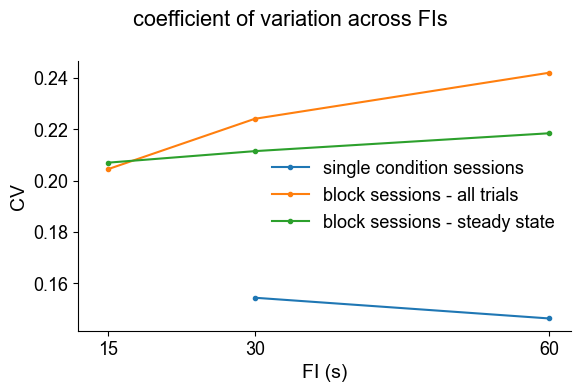

In [38]:
## robust CV and regular CV are the same; I guess the skew of this truncated distributions is not really relevant
## using vanilla CV
fig, axs = plt.subplots(1, figsize = (6,4), tight_layout = True)
axs.plot(FI_order, CV_unidf, '.-', label = 'single condition sessions')
axs.plot(FI_order, CV_blocksdf_all, '.-', label = 'block sessions - all trials')
axs.plot(FI_order, CV_blocksdf_steady, '.-', label = 'block sessions - steady state')

#plt.plot(FI_list, robustCV_unidf, '.--')
#plt.plot(FI_list, robustCV_blocksdf_all, '.--')
#plt.plot(FI_list, robustCV_blocksdf_steady, '.--')

axs.set_ylabel('CV')
axs.set_xlabel('FI (s)')
axs.set_xlim(12)
axs.set_xticks([15, 30, 60])

axs.legend(frameon = False)

figtitle = 'coefficient of variation across FIs'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|','_')}.pdf')


Text(0.5, 0.98, 'Example trials pooled from sessions in fixed conditions')

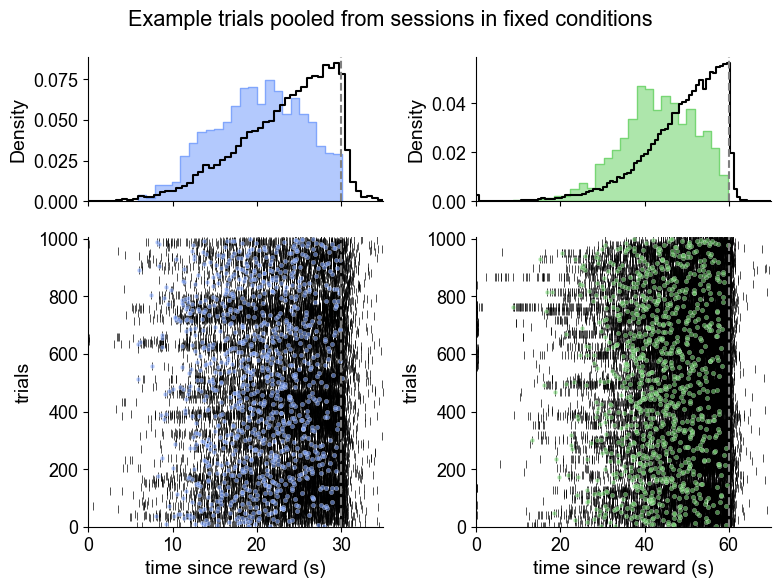

In [39]:
## cool color to contrast to black: #009E73

fig, axs = plt.subplots(2,2, figsize = (8,6), tight_layout = True, sharex='col', height_ratios=[1,2])

n_trials = 1000
# FI30 vs FI60

egdf = blocksdf.query(f'click == False and FI == 30 and bool_cp')
frac = n_trials/len(egdf)
egdf = egdf.sample(frac=frac, random_state=32).sort_values(by = 'trialno', ascending = True).reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,0], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = color_FI_blocks[1], fill=True,
             alpha = 0.6, binwidth=1)
sns.histplot(ax = axs[0,0], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False)
axs[0,0].axvline(30, color = 'grey', alpha = 1, ls = '--')

sns.scatterplot(ax = axs[1,0], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
sns.scatterplot(ax = axs[1,0], data = egdf, x = 'cp', y = 'trial', marker = 'o', alpha = 0.6,
                color = color_FI_blocks[1], s = 10)
axs[1,0].axvline(30, color = 'grey', alpha = 1, ls = '--')

axs[1,0].set_xlim(0,35)
axs[1,0].set_ylim(0,n_trials+5)
axs[1,0].set_xlabel('time since reward (s)')
axs[1,0].set_ylabel('trials')


## FI 60 ##
egdf = unidf.query(f'click == False and FI == 60 and bool_cp')
frac = n_trials/len(egdf)
egdf = egdf.sample(frac=frac, random_state=31).sort_values(by = 'trialno', ascending = True).reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,1], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = color_FI_blocks[2], fill=True,
             alpha = 0.6, binwidth=2)
sns.histplot(ax = axs[0,1], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False)
axs[0,1].axvline(60, color = 'grey', alpha = 1, ls = '--')

sns.scatterplot(ax = axs[1,1], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
sns.scatterplot(ax = axs[1,1], data = egdf, x = 'cp', y = 'trial', marker = 'o', alpha = 0.6,
                color = color_FI_blocks[2], s = 10)
axs[1,1].axvline(60, color = 'grey', alpha = 1, ls = '--')

axs[1,1].set_xlim(0,70)
axs[1,1].set_ylim(0,n_trials+5)
axs[1,1].set_xlabel('time since reward (s)')
axs[1,1].set_ylabel('trials')

figtitle = 'Example trials pooled from sessions in fixed conditions'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle}.png')

## reward magnitude and timing

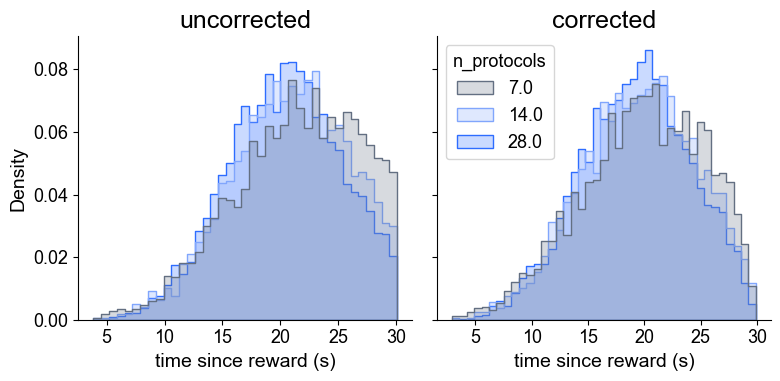

In [42]:
fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True, sharey = True)

sns.histplot(ax = axs[0], data = blocksdf.query('FI == 30 and click == False and experiment == "c" and n_protocols in [7,14,28]'),
             x = 'cp', hue = 'n_protocols', 
             stat = 'density', element = 'step', common_norm=False, palette = color_rwd_blocks)

sns.histplot(ax = axs[1], data = blocksdf.query('FI == 30 and click == False and experiment == "c" and n_protocols in [7,14,28]'),
             x = 'cp_corrected', hue = 'n_protocols', 
             stat = 'density', element = 'step', common_norm=False, palette = color_rwd_blocks)

for ii in range(2):
    axs[ii].set_xlabel('time since reward (s)')

axs[0].set_title('uncorrected')
axs[1].set_title('corrected')

remove_legend(axs[0])

figtitle = 'reward mangitude does not affect timing'
#fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle}.pdf')


<Axes: xlabel='cp', ylabel='Density'>

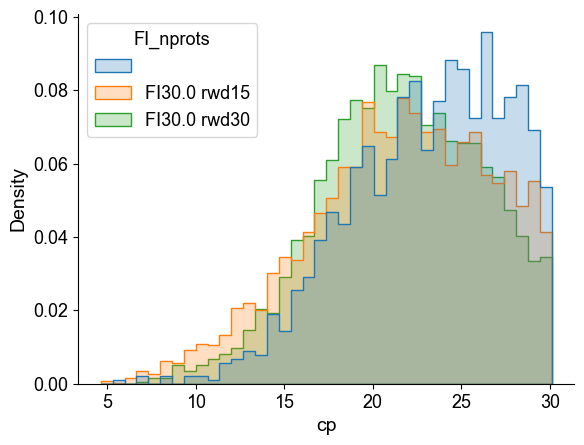

In [43]:
sns.histplot(data = unidf.query('click == False and batch != "batch1" and FI == 30'),
             x = 'cp', hue = 'FI_nprots', stat = 'density', element = 'step', common_norm=False)

## impulsive responses
prior to sustained pressing -- are they more frequent / earlier when reward magnitude is higher?

In [44]:
blocksdf['pre_cp_presses'] = blocksdf.apply(lambda x: x.lever_rel_s[x.lever_rel_s <= x.cp], axis = 1)

<Axes: xlabel='pre_cp_presses'>

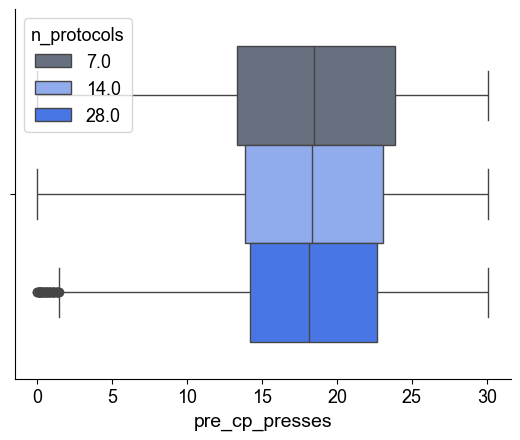

In [45]:
sns.boxplot(data = blocksdf.query('experiment == "c" and n_protocols in [7,14,28]').explode(['pre_cp_presses']).reset_index(),
             x = 'pre_cp_presses', hue = 'n_protocols', palette = color_rwd_blocks)#, common_norm=True, element = 'step')

<Axes: xlabel='first_press_s', ylabel='Count'>

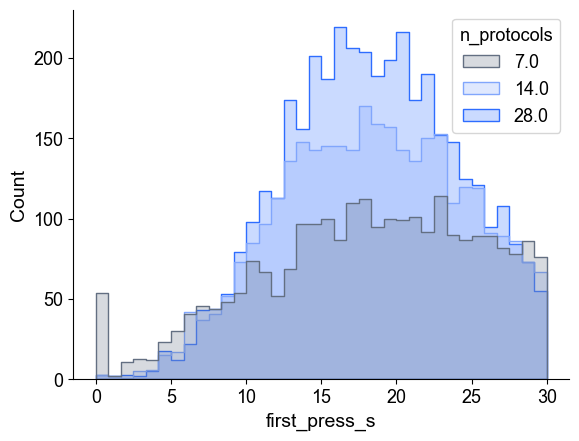

In [46]:
sns.histplot(data = blocksdf.query('experiment == "c" and click == False and bool_cp == True and first_press_s < 30 and n_protocols in [7,14,28]'),
             x = 'first_press_s', hue = 'n_protocols', palette = color_rwd_blocks, element = 'step', common_norm=False)

## click

In [48]:
click_palette = ['#bababa', '#7a7a7a'] #following the order of the click_order


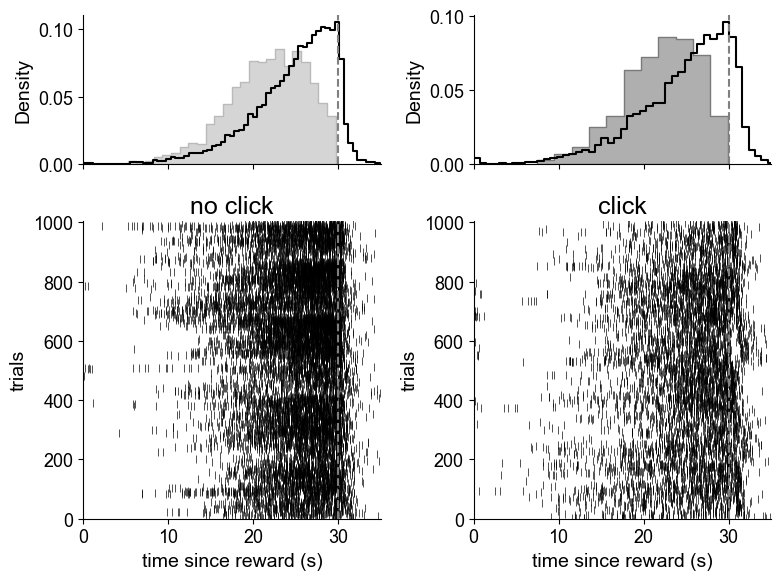

In [49]:
fig, axs = plt.subplots(2,2, figsize = (8,6), tight_layout = True, sharex = True, height_ratios=[1,2])

n_trials = 1000

# no click
animaldate = 'Carbon 220317'

egdf = unidf.query(f'click == False and FI == 30 and bool_cp == True and batch != "batch1"')#animaldate == "{animaldate}"')
frac = n_trials/len(egdf)
egdf = egdf.sample(frac=frac, random_state=31).sort_values(by = 'trialno', ascending = True).reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,0], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = click_palette[0], fill=True,
             alpha = 0.6, binwidth=1)
sns.histplot(ax = axs[0,0], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False)
axs[0,0].axvline(30, color = 'grey', alpha = 1, ls = '--')

axs[1,0].axvline(30, color = 'grey', alpha = 1, ls = '--')
sns.scatterplot(ax = axs[1,0], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
#sns.scatterplot(ax = axs[0], data = egdf, x = 'cp', y = 'trial', marker = 'o', alpha = 0.5)

axs[1,0].set_ylim(0,n_trials+5)
axs[1,0].set_xlabel('time since reward (s)')
axs[1,0].set_ylabel('trials')
axs[1,0].set_title(f'no click')


# click
animaldate = 'Sodium 220512'

#egdf = unidf.query(f'animaldate == "{animaldate}"')
egdf = unidf.query(f'click == True and FI == 30 and bool_cp == True and batch != "batch1"')#animaldate == "{animaldate}"')
frac = n_trials/len(egdf)
egdf = egdf.sample(frac=frac, random_state=42).sort_values(by = 'trialno', ascending = True).reset_index(drop = True)
egdf['trial'] = egdf.index +1

sns.histplot(ax = axs[0,1], data = egdf, x = 'cp',
             stat = 'density', element = 'step', color = click_palette[1], fill=True,
             alpha = 0.6, binwidth=2)
sns.histplot(ax = axs[0,1], data = egdf.explode('lever_rel_s'), x = 'lever_rel_s',
             stat = 'density', element = 'step', color = 'black', fill = False)
axs[0,1].axvline(30, color = 'grey', alpha = 1, ls = '--')

axs[1,1].axvline(30, color = 'grey', alpha = 1, ls = '--')
sns.scatterplot(ax = axs[1,1], data = egdf.explode('lever_rel_s'), y = 'trial', x = 'lever_rel_s',
                marker = '|', color = 'black')
#sns.scatterplot(ax = axs[1], data = egdf.query('bool_cp'), x = 'cp', y = 'trial', marker = 'o', alpha = 0.5)

axs[1,1].set_xlim(0,35)
axs[1,1].set_ylim(0,n_trials+5)
axs[1,1].set_xlabel('time since reward (s)')
axs[1,1].set_ylabel('trials')
axs[1,1].set_title(f'click')

figtitle = f'Example trials pooled from sessions in fixed conditions | click vs no click'
#plt.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.pdf')


In [50]:
# proportion of cp trials
#sns.boxplot(ax = axs[2], data = unidf.query('batch != "batch1"'), y = 'proportion_cp', x = 'click',
#            showfliers = False, palette=click_palette)
#axs[2].set_ylabel('proportion of transition trials')



NameError: name 'compute_rate_aligned_cp' is not defined

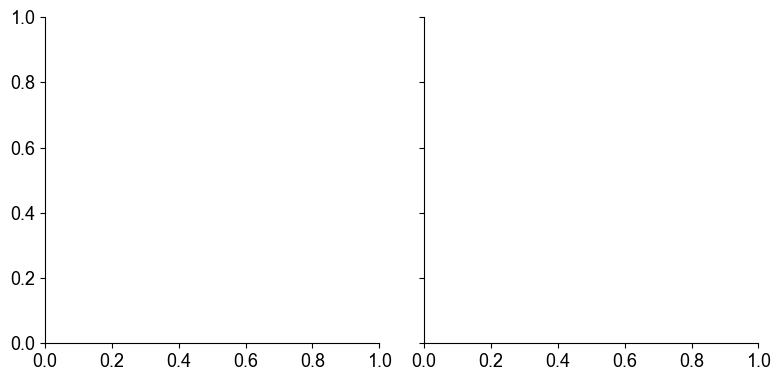

In [51]:
fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True, sharex = True, sharey = True)

## older version, sessions and animals "weight" the same
#for click in [False, True]:
#    bins, counts = compute_rate_aligned_cp(unidf, f'click == {click} and batch != "batch1"')
#    axs[0].plot(bins, counts, color = click_palette[click])
#
#    click_label = 'no click' if click == False else 'click'
#    bins, counts = compute_rate_aligned_cp(unidf, f'click == {click} and batch == "batch1" and animal != "Hydrogen"')
#    axs[1].plot(bins, counts, color = click_palette[click], label = click_label)


# SEM within animal (not using here), SD across animals
# mean within animal, and then mean of the means
for click in [False, True]:
    means = []
    for animal in unidf.query(f'click == {click} and batch != "batch1"').animal.unique():
        bins, counts = compute_rate_aligned_cp(unidf, f'animal == "{animal}"')
        means.append(counts)

    means = np.array(means)
    mean_of_means = np.mean(means, axis = 0)
    across_animals_std = np.std(means, axis = 0)

    upper_bound = mean_of_means + across_animals_std
    lower_bound = mean_of_means - across_animals_std
    axs[0].plot(bins, mean_of_means, color = click_palette[click])
    axs[0].fill_between(bins, lower_bound, upper_bound, color = click_palette[click], alpha = 0.2)

for click in [False, True]:
    means = []
    print(click)
    for animal in unidf.query(f'batch == "batch1" and animal != "Hydrogen"').animal.unique():
        bins, counts = compute_rate_aligned_cp(unidf, f'animal == "{animal}" and click == {click}')
        means.append(counts)

    means = np.array(means)
    mean_of_means = np.mean(means, axis = 0)
    across_animals_std = np.std(means, axis = 0)

    upper_bound = mean_of_means + across_animals_std
    lower_bound = mean_of_means - across_animals_std
    
    click_label = 'no click' if click == False else 'click'
    axs[1].plot(bins, mean_of_means, color = click_palette[click], label = click_label)
    axs[1].fill_between(bins, lower_bound, upper_bound, color = click_palette[click], alpha = 0.2)

axs[0].set_title('across experimental groups')
axs[1].set_title('within animal')

[axs[ii].set_xlabel('time since transition (s)') for ii in range(2)]
axs[0].set_ylabel('pressing rate (Hz)')
axs[1].legend()

figtitle = f'Click sessions have lower high pressing rates'
plt.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')

NameError: name 'click_order' is not defined

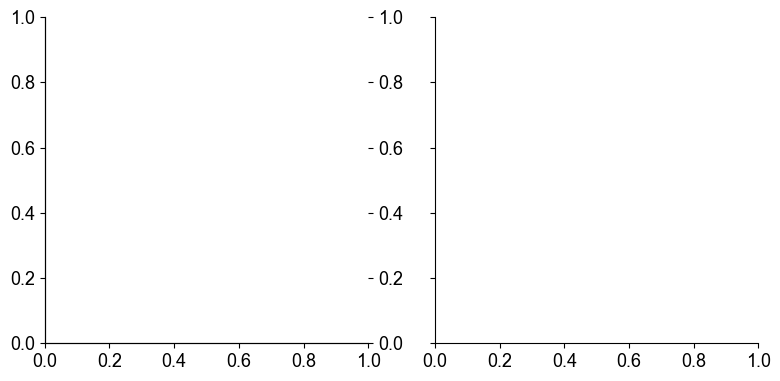

In [52]:
fig, axs = plt.subplots(1,2, tight_layout = True, figsize = (8,4), sharey = True)
click_label = ['no click', 'click']
batch_conds = ['batch != "batch1"', 'batch == "batch1"']


for jj in range(2):
    batch_cond = batch_conds[jj]
    twin_ax=axs[jj].twinx()

    for ii in range(2):
        click = click_order[ii]
        _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(unidf.query(f'click == {click} and bool_cp and count_lever > 3 and {batch_cond}'),[-3,12],bin_width=.2)
        axs[jj].plot(bins[frac_finished_trials<=0.5], mean_rate[frac_finished_trials<=0.5], color = click_palette[ii], label = click_label[ii])
        axs[jj].plot(bins[frac_finished_trials>0.5], mean_rate[frac_finished_trials>0.5], color = click_palette[ii],ls = 'dotted')

        twin_ax.fill_between(bins,np.zeros(len(SEM)), SEM, color=click_palette[ii], alpha = 0.2)
        twin_ax.set_ylabel('SEM', color='grey')
        twin_ax.tick_params(axis='y', labelcolor='grey')

        twin_ax.set_ylim(0,.1)

axs[0].set_ylabel('pressing rate (Hz)')
axs[0].set_title('across experimental groups')
axs[1].set_title('within animal')

axs[0].legend(frameon=False)

#for animal in animal_order[1:]:
#    for ii in range(2):
#        click = click_order[ii]
#        _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(unidf.query(f'click == {click} and bool_cp and count_lever > 3 and animal == "{animal}"'),[-3,12],bin_width=.2)
#        axs[1].plot(bins, mean_rate, color = click_palette[ii], label = click_label[ii], lw = 0.5)
#
#
#for animal in unidf.query('batch != "batch1"').animal.unique():
#    for ii in range(2):
#        click = click_order[ii]
#        _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(unidf.query(f'click == {click} and bool_cp and count_lever > 3 and animal == "{animal}"'),[-3,12],bin_width=.2)
#        axs[0].plot(bins, mean_rate, color = click_palette[ii], label = click_label[ii], alpha = 0.3)




# Add an inset axis to axs[1] in the bottom right
ax_inset = inset_axes(axs[1], width="30%", height="50%", loc='lower right', borderpad=1)

df = unidf.query('bool_cp and count_lever > 3').groupby('animaldate').agg({
    'batch': 'first',
    'animal': 'first',
    'date': 'first',
    'FI': 'first',
    'click': 'first',
    'rateH': list
}).reset_index()
df['av_rateH'] = df.rateH.apply(lambda x: np.mean(x))

sns.boxplot(ax = ax_inset, data = df.query(f'batch == "batch1"'), y = 'av_rateH', x = 'click', showfliers = False,
            palette=click_palette)
for animal in animal_order:
    ax_inset.plot([0,1],
            [df.query(f'animal == "{animal}" and click == False').av_rateH.mean(),
             df.query(f'animal == "{animal}" and click == True').av_rateH.mean()],
             '.', color = '#e3e3e3', ms = 17)
for animal in animal_order:
    ax_inset.plot([0,1],
            [df.query(f'animal == "{animal}" and click == False').av_rateH.mean(),
             df.query(f'animal == "{animal}" and click == True').av_rateH.mean()],
             '.-', color = '#2e2e2e', ms = 10)
    
# Remove x-axis ticks and labels, and hide the axis line
ax_inset.set_xticks([])
ax_inset.set_xticklabels([])
ax_inset.spines['bottom'].set_visible(False)
ax_inset.xaxis.set_visible(False)
ax_inset.set_xlabel('')
#ax_inset.set_ylim(0)
ax_inset.set_ylabel('pressing rate (Hz)', fontsize = 10)
for label in ax_inset.get_yticklabels():
    label.set_fontsize(10)

[axs[ii].set_xlabel('time since transition (s)') for ii in range(2)]
axs[0].set_ylim(0)

figtitle = f'Click sessions have lower high pressing rates'
#plt.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.pdf')

Text(0.5, 0.98, 'Transition point is unaffected by the click as long as properly corrected for differences in pressing rate')

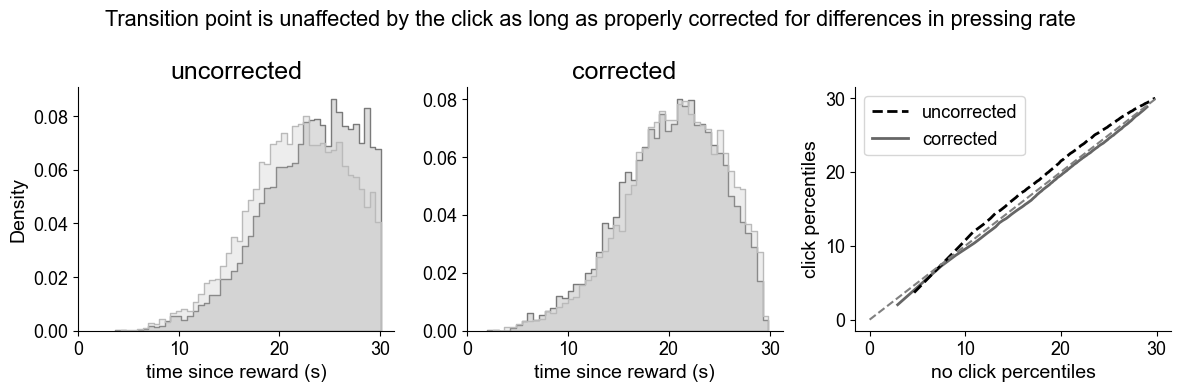

In [53]:
fig, axs = plt.subplots(1,3, figsize = (12,4), tight_layout = True)#, sharey = True)

sns.histplot(ax = axs[0], data = unidf.query('batch != "batch1" and FI == 30'), x = 'cp', hue = 'click', element = 'step', stat = 'density', common_norm=False, palette=click_palette)
sns.histplot(ax = axs[1], data = unidf.query('batch != "batch1" and FI == 30'), x = 'cp_corrected', hue = 'click', element = 'step', stat = 'density', common_norm=False, palette=click_palette)
#axs[0,0].set_ylabel('density - FI30')
axs[1].set_ylabel('')
[axs[ii].set_xlabel('time since reward (s)') for ii in range(2)]
[axs[ii].set_xlim(0) for ii in range(2)]

axs[0].set_title('uncorrected')
axs[1].set_title('corrected')

#sns.histplot(ax = axs[1,0], data = unidf.query('FI == 60'), x = 'cp', hue = 'click', element = 'step', stat = 'density', common_norm=False)
#sns.histplot(ax = axs[1,1], data = unidf.query('FI == 60'), x = 'corrected_cp', hue = 'click', element = 'step', stat = 'density', common_norm=False)
#axs[1,0].set_ylabel('density - FI60')
#axs[1,1].set_ylabel('')
#axs[1,0].set_xlabel('transition point (s)')
#axs[1,1].set_xlabel('transition point, corrected (s)')


q_noclick = np.nanquantile(unidf.query('batch != "batch1" and FI == 30 and click == False').cp.values,np.arange(0,1,.01))
q_click = np.nanquantile(unidf.query('batch != "batch1" and FI == 30 and click == True').cp.values,np.arange(0,1,.01))

q_noclick_corrected = np.nanquantile(unidf.query('batch != "batch1" and FI == 30 and click == False').cp_corrected.values,np.arange(0,1,.01))
q_click_corrected = np.nanquantile(unidf.query('batch != "batch1" and FI == 30 and click == True').cp_corrected.values,np.arange(0,1,.01))

axs[2].plot(q_noclick, q_click, color = 'black', ls = '--', lw = 2, label = 'uncorrected')
axs[2].plot(q_noclick_corrected, q_click_corrected, color = 'black', alpha = 0.6, lw = 2, label = 'corrected')
axs[2].plot([0,30],[0,30], '--', color = 'grey')

axs[2].set_xlabel('no click percentiles')
axs[2].set_ylabel('click percentiles')
axs[2].legend()

[remove_legend(axs[ii]) for ii in range(2)]

figtitle = f'Transition point is unaffected by the click as long as properly corrected for differences in pressing rate'
plt.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.pdf')

## new -- for thesis presentation

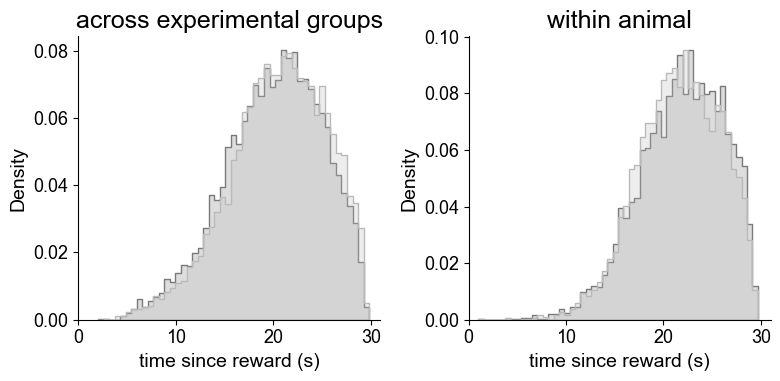

In [54]:
fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True, sharex = True)

sns.histplot(ax = axs[0], data = unidf.query('batch != "batch1" and FI == 30'), x = 'cp_corrected', hue = 'click',
             element = 'step', stat = 'density', common_norm=False, palette=click_palette)

sns.histplot(ax = axs[1], data = unidf.query('batch == "batch1" and FI == 30'), x = 'cp_corrected', hue = 'click',
             stat = 'density', element = 'step', common_norm=False, palette=click_palette)

axs[0].set_title('across experimental groups')
axs[1].set_title('within animal')

for ii in range(2):
    axs[ii].set_xlabel('time since reward (s)')
    remove_legend(axs[ii])

axs[0].set_xlim(0,31)

figtitle = f'click transition point corrected_across groups and within animal'
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.pdf')

NameError: name 'click_order' is not defined

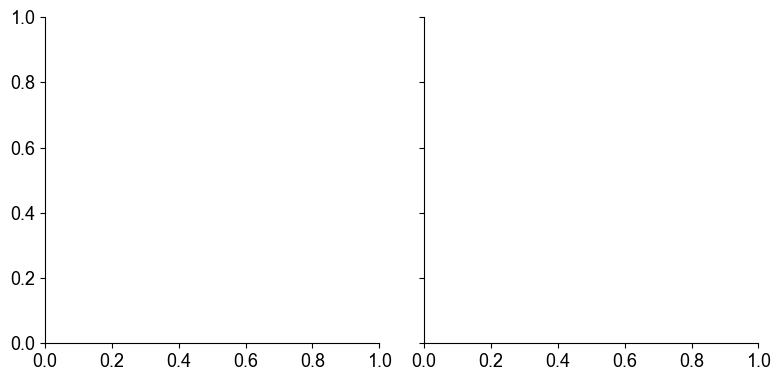

In [55]:
fig, axs = plt.subplots(1,2, tight_layout = True, figsize = (8,4), sharey = True)
click_label = ['no click', 'click']
batch_conds = ['batch != "batch1"', 'batch == "batch1"']


for jj in range(2):
    batch_cond = batch_conds[jj]

    for ii in range(2):
        click = click_order[ii]
        _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(unidf.query(f'click == {click} and bool_cp and count_lever > 3 and {batch_cond}'),[-3,12],bin_width=.2)
        axs[jj].plot(bins[frac_finished_trials<=0.5], mean_rate[frac_finished_trials<=0.5], color = click_palette[ii], label = click_label[ii])
        axs[jj].plot(bins[frac_finished_trials>0.5], mean_rate[frac_finished_trials>0.5], color = click_palette[ii],ls = 'dotted')

axs[0].set_ylabel('pressing rate (Hz)')
axs[0].set_title('across experimental groups')
axs[1].set_title('within animal')

axs[0].legend(frameon=False)

#for animal in animal_order[1:]:
#    for ii in range(2):
#        click = click_order[ii]
#        _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(unidf.query(f'click == {click} and bool_cp and count_lever > 3 and animal == "{animal}"'),[-3,12],bin_width=.2)
#        axs[1].plot(bins, mean_rate, color = click_palette[ii], label = click_label[ii], lw = 0.5)
#
#
#for animal in unidf.query('batch != "batch1"').animal.unique():
#    for ii in range(2):
#        click = click_order[ii]
#        _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(unidf.query(f'click == {click} and bool_cp and count_lever > 3 and animal == "{animal}"'),[-3,12],bin_width=.2)
#        axs[0].plot(bins, mean_rate, color = click_palette[ii], label = click_label[ii], alpha = 0.3)




# Add an inset axis to axs[1] in the bottom right
ax_inset = inset_axes(axs[1], width="30%", height="50%", loc='lower right', borderpad=1)

df = unidf.query('bool_cp and count_lever > 3').groupby('animaldate').agg({
    'batch': 'first',
    'animal': 'first',
    'date': 'first',
    'FI': 'first',
    'click': 'first',
    'rateH': list
}).reset_index()
df['av_rateH'] = df.rateH.apply(lambda x: np.mean(x))

sns.boxplot(ax = ax_inset, data = df.query(f'batch == "batch1"'), y = 'av_rateH', x = 'click', showfliers = False,
            palette=click_palette)
for animal in animal_order:
    ax_inset.plot([0,1],
            [df.query(f'animal == "{animal}" and click == False').av_rateH.mean(),
             df.query(f'animal == "{animal}" and click == True').av_rateH.mean()],
             '.', color = '#e3e3e3', ms = 17)
for animal in animal_order:
    ax_inset.plot([0,1],
            [df.query(f'animal == "{animal}" and click == False').av_rateH.mean(),
             df.query(f'animal == "{animal}" and click == True').av_rateH.mean()],
             '.-', color = '#2e2e2e', ms = 10)
    
# Remove x-axis ticks and labels, and hide the axis line
ax_inset.set_xticks([])
ax_inset.set_xticklabels([])
ax_inset.spines['bottom'].set_visible(False)
ax_inset.xaxis.set_visible(False)
ax_inset.set_xlabel('')
#ax_inset.set_ylim(0)
ax_inset.set_ylabel('pressing rate (Hz)', fontsize = 10)
for label in ax_inset.get_yticklabels():
    label.set_fontsize(10)

[axs[ii].set_xlabel('time since transition (s)') for ii in range(2)]
axs[0].set_ylim(0)

figtitle = f'no SEM Click sessions have lower high pressing rates'
#plt.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.pdf')

C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\393924811.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax = axs[2], data = proportion_cp_boxplot_df, y = 'proportion_cp', x = 'click',


Text(0.5, 0.98, 'Transition point probability | click vs no click')

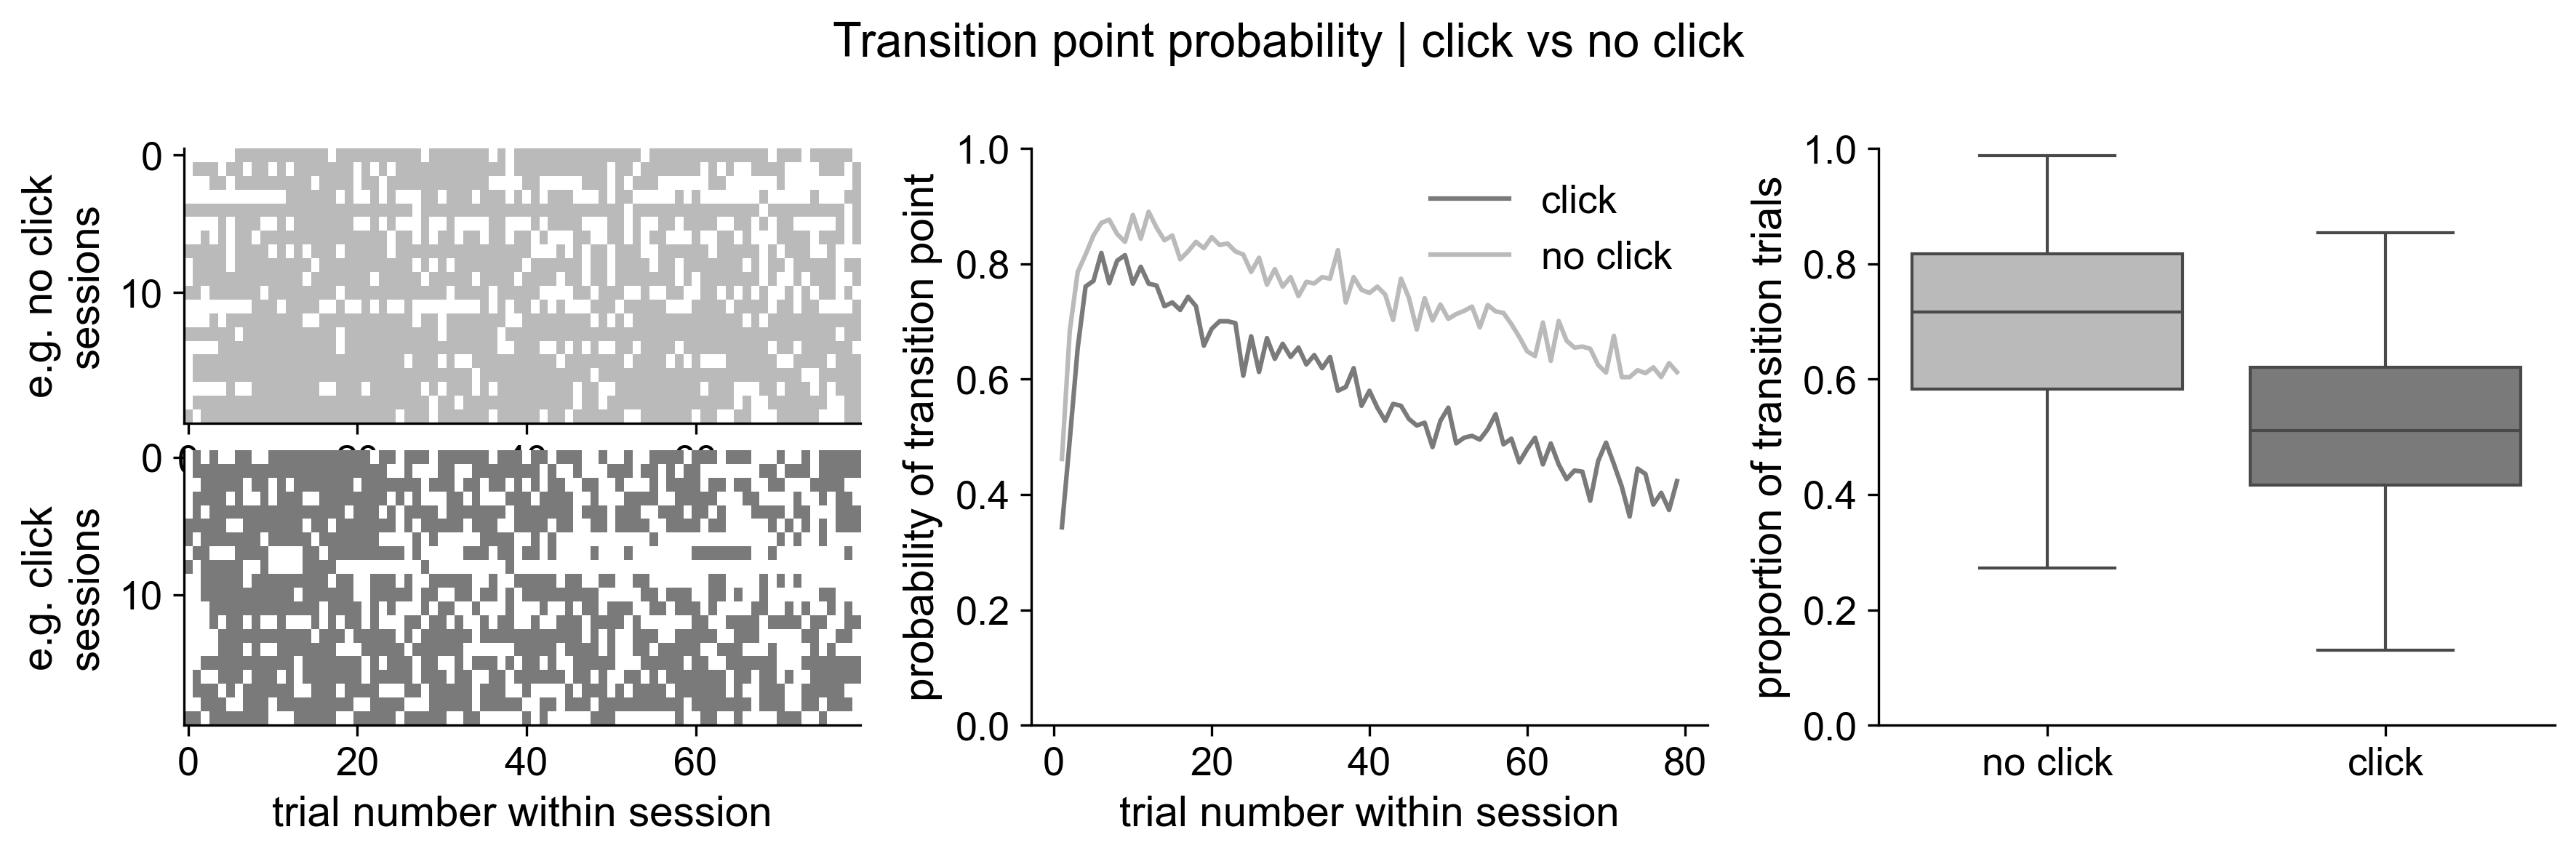

In [56]:
from matplotlib.gridspec import GridSpecFromSubplotSpec
import random
from matplotlib.colors import LinearSegmentedColormap

## probability of transition point -- click vs no click

## include proportion of transition trials as well


unidf.groupby('trialno_withinsession')

## it's more fair to do this for the 2 FIs; can be on the same plot
prob_transition_df = pd.DataFrame()
prob_transition_df['trialno'] = np.arange(1,80)
prob_transition_df['count_cp_trials_click'] = unidf.query('click == True').groupby('trialno_withinsession').bool_cp.sum().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_cp_trials_no_click'] = unidf.query('click == False').groupby('trialno_withinsession').bool_cp.sum().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_trials_click'] = unidf.query('click == True').groupby('trialno_withinsession').bool_cp.count().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_trials_no_click'] = unidf.query('click == False').groupby('trialno_withinsession').bool_cp.count().reindex(prob_transition_df.trialno).fillna(0).values

prob_transition_df['prob_cp_click'] = prob_transition_df.count_cp_trials_click / prob_transition_df.count_trials_click
prob_transition_df['prob_cp_no_click'] = prob_transition_df.count_cp_trials_no_click / prob_transition_df.count_trials_no_click

prob_transition_df['count_cp_trials_click_FI30'] = unidf.query('click == True and FI == 30').groupby('trialno_withinsession').bool_cp.sum().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_cp_trials_no_click_FI30'] = unidf.query('click == False and FI == 30').groupby('trialno_withinsession').bool_cp.sum().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_trials_click_FI30'] = unidf.query('click == True and FI == 30').groupby('trialno_withinsession').bool_cp.count().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_trials_no_click_FI30'] = unidf.query('click == False and FI == 30').groupby('trialno_withinsession').bool_cp.count().reindex(prob_transition_df.trialno).fillna(0).values

prob_transition_df['prob_cp_click_FI30'] = prob_transition_df.count_cp_trials_click_FI30 / prob_transition_df.count_trials_click_FI30
prob_transition_df['prob_cp_no_click_FI30'] = prob_transition_df.count_cp_trials_no_click_FI30 / prob_transition_df.count_trials_no_click_FI30

prob_transition_df['count_cp_trials_click_FI60'] = unidf.query('click == True and FI == 60').groupby('trialno_withinsession').bool_cp.sum().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_cp_trials_no_click_FI60'] = unidf.query('click == False and FI == 60').groupby('trialno_withinsession').bool_cp.sum().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_trials_click_FI60'] = unidf.query('click == True and FI == 60').groupby('trialno_withinsession').bool_cp.count().reindex(prob_transition_df.trialno).fillna(0).values
prob_transition_df['count_trials_no_click_FI60'] = unidf.query('click == False and FI == 60').groupby('trialno_withinsession').bool_cp.count().reindex(prob_transition_df.trialno).fillna(0).values

prob_transition_df['prob_cp_click_FI60'] = prob_transition_df.count_cp_trials_click_FI60 / prob_transition_df.count_trials_click_FI60
prob_transition_df['prob_cp_no_click_FI60'] = prob_transition_df.count_cp_trials_no_click_FI60 / prob_transition_df.count_trials_no_click_FI60


proportion_cp_boxplot_df = pd.DataFrame({
    'animaldate': unidf.groupby('animaldate').proportion_cp.unique().reset_index()['animaldate'],
    'click': unidf.groupby('animaldate').click.unique().reset_index()['click'],
    'proportion_cp': unidf.groupby('animaldate').proportion_cp.unique().reset_index()['proportion_cp']
})
proportion_cp_boxplot_df['click'] = proportion_cp_boxplot_df['click'].apply(lambda x: x[0])
proportion_cp_boxplot_df['click'] = proportion_cp_boxplot_df['click'].replace({1.0: 'click', 0.0: 'no click'})
proportion_cp_boxplot_df['proportion_cp'] = proportion_cp_boxplot_df['proportion_cp'].apply(lambda x: x[0])


## showing single trials throughout multiple sessions
random.seed(47)  

n_sessions = 20

random_sessions_noclick = random.sample(list(unidf.query('total_trials_within_session > 80 and click == False and batch != "batch1"').animaldate.unique()), n_sessions)
random_sessions_click = random.sample(list(unidf.query('total_trials_within_session > 80 and click == True and batch != "batch1"').animaldate.unique()), n_sessions)

grouped_df_noclick = unidf.query(f'animaldate in {random_sessions_noclick}').groupby('animaldate')['bool_cp'].apply(list).reset_index()
grouped_df_noclick['bool_cp'] = grouped_df_noclick.bool_cp.apply(lambda x: x[:80])

grouped_df_click = unidf.query(f'animaldate in {random_sessions_click}').groupby('animaldate')['bool_cp'].apply(list).reset_index()
grouped_df_click['bool_cp'] = grouped_df_click.bool_cp.apply(lambda x: x[:80])


noclick_cmap = LinearSegmentedColormap.from_list('noclick_cmap', ['white', click_palette[0]])
click_cmap = LinearSegmentedColormap.from_list('click_cmap', ['white', click_palette[1]])



fig, axs = plt.subplots(1,3, figsize = (12,4), tight_layout = True, dpi = 300)

axs[0].remove()

# Create a GridSpec inside the area of axs[0]
gs = fig.add_gridspec(1, 3)  # Same shape as the original layout
sub_gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0], hspace=0.1)

# Now create two vertically stacked axes in the original axs[0] space
ax0_top = fig.add_subplot(sub_gs[0])
ax0_bottom = fig.add_subplot(sub_gs[1], sharex = ax0_top)

ax0_top.imshow(grouped_df_noclick.bool_cp.apply(lambda x: np.array(x).astype(int)).tolist(), aspect='auto', cmap=noclick_cmap)
ax0_bottom.imshow(grouped_df_click.bool_cp.apply(lambda x: np.array(x).astype(int)).tolist(), aspect='auto', cmap=click_cmap)

ax0_bottom.set_xlabel('trial number within session')
ax0_top.set_ylabel('e.g. no click\nsessions')
ax0_bottom.set_ylabel('e.g. click\nsessions')


sns.lineplot(ax = axs[1], data = prob_transition_df, x = 'trialno', y = 'prob_cp_click', color = click_palette[1], label = 'click')
sns.lineplot(ax = axs[1], data = prob_transition_df, x = 'trialno', y = 'prob_cp_no_click', color = click_palette[0], label = 'no click')
axs[1].legend(frameon = False)
#sns.lineplot(ax = axs[0], data = prob_transition_df, x = 'trialno', y = 'prob_cp_click_FI30', color = color_FI_blocks[1], label = 'click FI30')
#sns.lineplot(ax = axs[0], data = prob_transition_df, x = 'trialno', y = 'prob_cp_no_click_FI30', color = color_FI_blocks[1], label = 'no click FI30')
#sns.lineplot(ax = axs[0], data = prob_transition_df, x = 'trialno', y = 'prob_cp_click_FI60', color = color_FI_blocks[2], label = 'click FI60')
#sns.lineplot(ax = axs[0], data = prob_transition_df, x = 'trialno', y = 'prob_cp_no_click_FI60', color = color_FI_blocks[2], label = 'no click FI60')

sns.boxplot(ax = axs[2], data = proportion_cp_boxplot_df, y = 'proportion_cp', x = 'click',
            palette=click_palette, showfliers=False)

axs[2].set_xlabel('')
axs[1].set_xlabel('trial number within session')
axs[1].set_ylabel('probability of transition point')
[axs[ii].set_ylim(0,1) for ii in range(1,3)]

axs[2].set_ylabel('proportion of transition trials')

figtitle = f'Transition point probability | click vs no click'
plt.suptitle(figtitle)

#plt.savefig(fr'{fig_path}/{figtitle.replace('|','_')}.png')
#plt.savefig(fr'{fig_path}/{figtitle.replace('|','_')}.pdf')



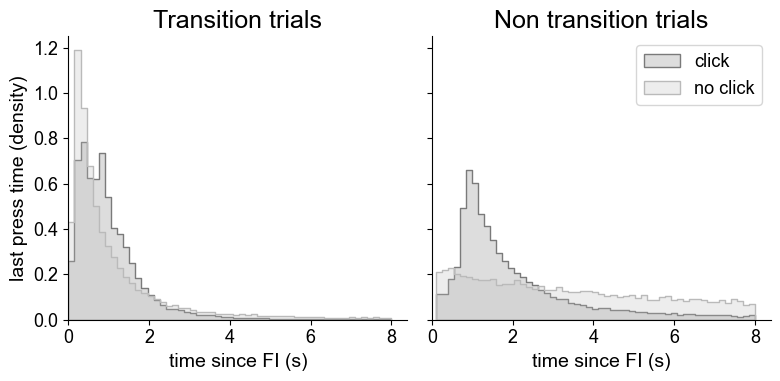

In [58]:
latency_lastpress_df = pd.concat([
    unidf.query('batch != "batch1"')[['click', 'latency_FI_lastpress']],
    blocksdf[['bool_cp', 'click', 'latency_FI_lastpress', 'FI']]
], ignore_index=True)


fig, axs = plt.subplots(1, 2, figsize = (8,4), tight_layout = True, sharey = True, sharex=True)

sns.histplot(ax = axs[0], data = latency_lastpress_df.query('bool_cp == True and latency_FI_lastpress > 0 and latency_FI_lastpress < 8'), x = 'latency_FI_lastpress',
             hue = 'click', stat = 'density', element = 'step', common_norm=False, binwidth=.15,
             hue_order = [False, True], palette=click_palette)

sns.histplot(ax = axs[1], data = latency_lastpress_df.query('bool_cp == False and latency_FI_lastpress > 0 and latency_FI_lastpress < 8'), x = 'latency_FI_lastpress',
             hue = 'click', stat = 'density', element = 'step', common_norm=False, binwidth=.15,
             hue_order = [False, True], palette=click_palette)

remove_legend(axs[0])
axs[1].legend(title=None, labels=['click', 'no click'])

[axs[ii].set_xlabel('time since FI (s)') for ii in range(2)]
axs[0].set_ylabel('last press time (density)')
axs[0].set_xlim(0)

axs[0].set_title('Transition trials')
axs[1].set_title('Non transition trials')


figtitle = f'Non transition trials exhibit an RT-like distribution when the click is present'
#plt.suptitle(figtitle)

#plt.savefig(fr'{fig_path}/{figtitle.replace('|','_')}.png')
#plt.savefig(fr'{fig_path}/{figtitle.replace('|','_')}.pdf')

In [59]:

dataframes.normalise_column(unidf, ['lever_rel_s', 'first_press_s'])
fig_df = unidf.query('click == True')

dd = dataframes.expand_df(fig_df, 'lever_rel_s', ['FI', 'trialno'])
dd['lever_rel_s_normalised'] = np.hstack(fig_df.lever_rel_s_normalised.values)

NameError: name 'dataframes' is not defined

C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\715123486.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(ax = axs[0,0], data = unidf.query('click == False'), x = 'cp',
C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\715123486.py:7: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(ax = axs[0,1], data = unidf.query('click == False'), x = 'cp_normalised',
C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\715123486.py:21: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(ax = axs[1,0], data = unidf.query('click == True'), x = 'cp',
C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\715123486.py:25: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an unin

NameError: name 'figures' is not defined

c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


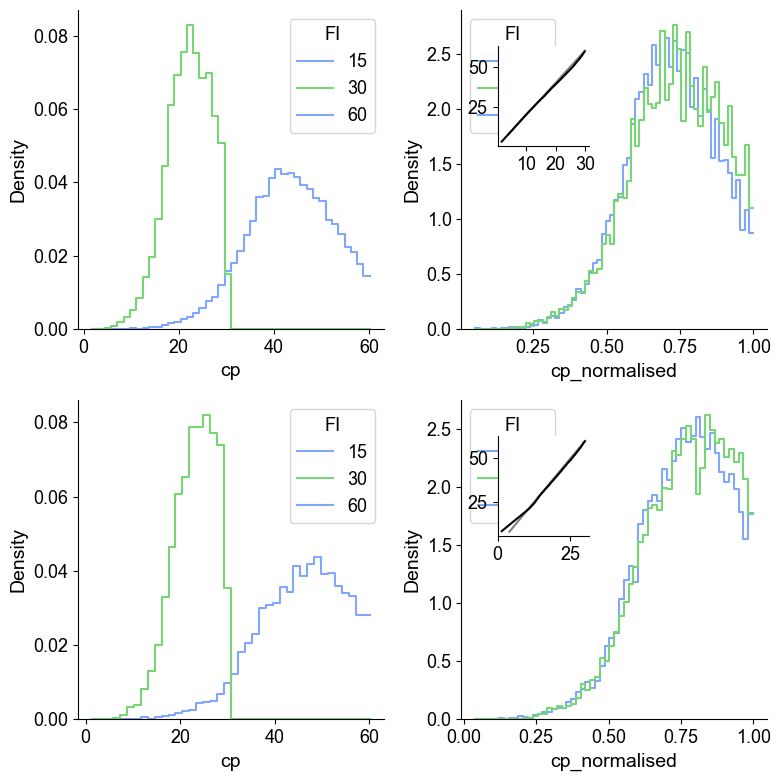

In [60]:


fig, axs = plt.subplots(2,2, figsize = (8,8), tight_layout = True)

sns.histplot(ax = axs[0,0], data = unidf.query('click == False'), x = 'cp',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks[1:],
    stat = 'density', common_norm= False,
    element = 'step', fill = False)
sns.histplot(ax = axs[0,1], data = unidf.query('click == False'), x = 'cp_normalised',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks[1:],
    stat = 'density', common_norm = False,
    element = 'step', fill = False)#, binwidth = .02)

#percentiles inset
axs01_in = inset_axes(axs[0,1], width = "30%", height = 1, loc = 2, borderpad = 2)
axs01_in.plot([4,30], [8,60], 'grey')
axs01_in.plot(np.quantile(unidf.query('click == False and FI == 30').cp.dropna().values, np.arange(0,1,.01)),
         np.quantile(unidf.query('click == False and FI == 60').cp.dropna().values, np.arange(0,1,.01)),
         'black')
axs01_in.set_xlabel('')
axs01_in.set_ylabel('')

sns.histplot(ax = axs[1,0], data = unidf.query('click == True'), x = 'cp',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks[1:],
    stat = 'density', common_norm= False,
    element = 'step', fill = False)
sns.histplot(ax = axs[1,1], data = unidf.query('click == True'), x = 'cp_normalised',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks[1:],
    stat = 'density', common_norm = False,
    element = 'step', fill = False)#, binwidth = .02)

#percentiles inset
axs11_in = inset_axes(axs[1,1], width = "30%", height = 1, loc = 2, borderpad = 2)
axs11_in.plot([4,30], [8,60], 'grey')
axs11_in.plot(np.quantile(unidf.query('click == True and FI == 30').cp.dropna().values, np.arange(0,1,.01)),
         np.quantile(unidf.query('click == True and FI == 60').cp.dropna().values, np.arange(0,1,.01)),
         'black')
axs01_in.set_xlabel('')
axs01_in.set_ylabel('')

figures.remove_legend([axs[1,ii] for ii in range(2)])
figures.remove_legend(axs[0,1])

axs[0,0].set_ylabel('transition point density - no click')
axs[1,0].set_ylabel('transition point density - click')

[axs[ii,1].set_ylabel('') for ii in range(2)]

[axs[ii,0].set_xlim(0,65) for ii in range(2)]
[axs[ii,1].set_xlim(0,1.1) for ii in range(2)]

[axs[0,ii].set_xlabel('') for ii in range(2)]

axs[1,0].set_xlabel('time since reward (s)')
axs[1,1].set_xlabel('time since reward (normalised)')

#fig_name = figures.produce_fig_titles('Scalar timing in the transition distributions')

#plt.savefig(fr'{fig_path}/{fig_name}.png', facecolor = 'white')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\158125832.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(ax = axs[0], data = unidf.query('click == False'), x = 'cp',
C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\158125832.py:7: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(ax = axs[1], data = unidf.query('click == False'), x = 'cp_normalised',


NameError: name 'figures' is not defined

c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


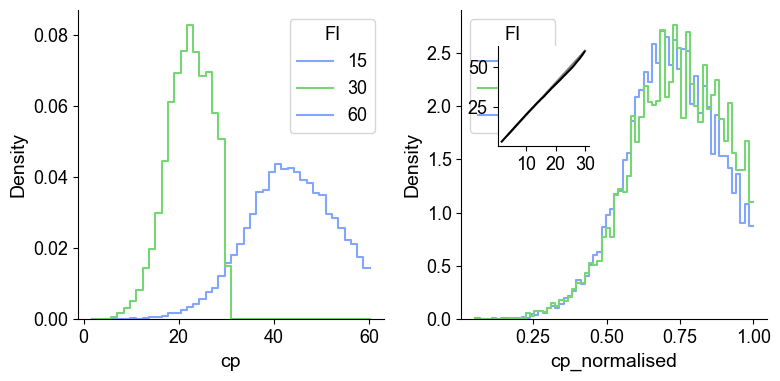

In [61]:
fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True)

sns.histplot(ax = axs[0], data = unidf.query('click == False'), x = 'cp',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks[1:],
    stat = 'density', common_norm= False,
    element = 'step', fill = False)
sns.histplot(ax = axs[1], data = unidf.query('click == False'), x = 'cp_normalised',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks[1:],
    stat = 'density', common_norm = False,
    element = 'step', fill = False)#, binwidth = .02)

#percentiles inset
axs01_in = inset_axes(axs[1], width = "30%", height = 1, loc = 2, borderpad = 2)
axs01_in.plot([4,30], [8,60], 'grey')
axs01_in.plot(np.quantile(unidf.query('click == False and FI == 30').cp.dropna().values, np.arange(0,1,.01)),
         np.quantile(unidf.query('click == False and FI == 60').cp.dropna().values, np.arange(0,1,.01)),
         'black')
axs01_in.set_xlabel('')
axs01_in.set_ylabel('')


#figures.remove_legend([axs[1,ii] for ii in range(2)])
figures.remove_legend(axs[1])

axs[0].set_ylabel('transition point density - no click')

axs[1].set_ylabel('')

axs[0].set_xlim(0,65) 
axs[1].set_xlim(0,1.1)


axs[0].set_xlabel('time since reward (s)')
axs[1].set_xlabel('time since reward (normalised)')

#fig_name = figures.produce_fig_titles('Scalar timing in the transition distributions - no blocks')

#plt.savefig(fr'{poster_path}/{fig_name}.pdf')#, facecolor = 'white')
plt.show()

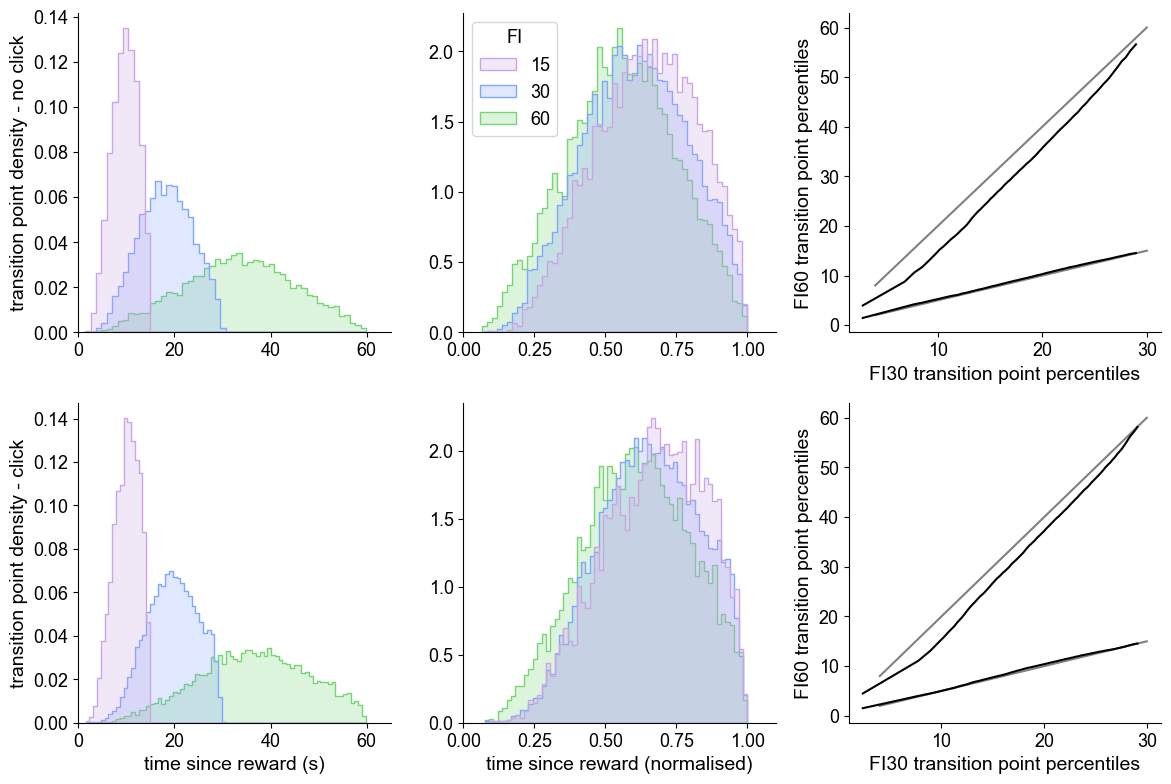

In [62]:
fig, axs = plt.subplots(2,3, figsize = (12,8), tight_layout = True)

sns.histplot(ax = axs[0,0], data = blocksdf.query('click == False and experiment != "c"'), x = 'cp_corrected',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm= False,
    element = 'step')
sns.histplot(ax = axs[0,1], data = blocksdf.query('click == False and experiment != "c"'), x = 'cp_corrected_normalised',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm = False,
    element = 'step')#, binwidth = .02)
axs[0,2].plot([4,30], [2,15], 'grey')
axs[0,2].plot([4,30], [8,60], 'grey')
axs[0,2].plot(np.quantile(blocksdf.query('click == False and FI == 30').cp_corrected.dropna().values, np.arange(0,1,.01)),
         np.quantile(blocksdf.query('click == False and FI == 15').cp_corrected.dropna().values, np.arange(0,1,.01)),
         'black')
axs[0,2].plot(np.quantile(blocksdf.query('click == False and FI == 30').cp_corrected.dropna().values, np.arange(0,1,.01)),
         np.quantile(blocksdf.query('click == False and FI == 60').cp_corrected.dropna().values, np.arange(0,1,.01)),
         'black')

sns.histplot(ax = axs[1,0], data = blocksdf.query('click == True'), x = 'cp_corrected',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm= False,
    element = 'step')
sns.histplot(ax = axs[1,1], data = blocksdf.query('click == True'), x = 'cp_corrected_normalised',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm = False,
    element = 'step')#, binwidth = .02)
axs[1,2].plot([4,30], [2,15], 'grey')
axs[1,2].plot([4,30], [8,60], 'grey')
axs[1,2].plot(np.quantile(blocksdf.query('click == True and FI == 30').cp_corrected.dropna().values, np.arange(0,1,.01)),
         np.quantile(blocksdf.query('click == True and FI == 15').cp_corrected.dropna().values, np.arange(0,1,.01)),
         'black')
axs[1,2].plot(np.quantile(blocksdf.query('click == True and FI == 30').cp_corrected.dropna().values, np.arange(0,1,.01)),
         np.quantile(blocksdf.query('click == True and FI == 60').cp_corrected.dropna().values, np.arange(0,1,.01)),
         'black')
    
remove_legend([axs[1,ii] for ii in range(2)])
remove_legend(axs[0,0])

axs[0,2].set_xlabel('FI30 transition point percentiles')
axs[0,2].set_ylabel('FI60 transition point percentiles')

axs[1,2].set_xlabel('FI30 transition point percentiles')
axs[1,2].set_ylabel('FI60 transition point percentiles')

axs[0,0].set_ylabel('transition point density - no click')
axs[1,0].set_ylabel('transition point density - click')

[axs[ii,1].set_ylabel('') for ii in range(2)]

[axs[ii,0].set_xlim(0,65) for ii in range(2)]
[axs[ii,1].set_xlim(0,1.1) for ii in range(2)]

[axs[0,ii].set_xlabel('') for ii in range(2)]

axs[1,0].set_xlabel('time since reward (s)')
axs[1,1].set_xlabel('time since reward (normalised)')

#fig_name = figures.produce_fig_titles('Scalar timing in the transition distributions (corrected)')
#plt.savefig(rf"C:\Users\Utilizador\Documents\git\ratanalysis\analysis_behaviour\figures\cp_blocks\{fig_name}.png", facecolor = 'white')
plt.show()

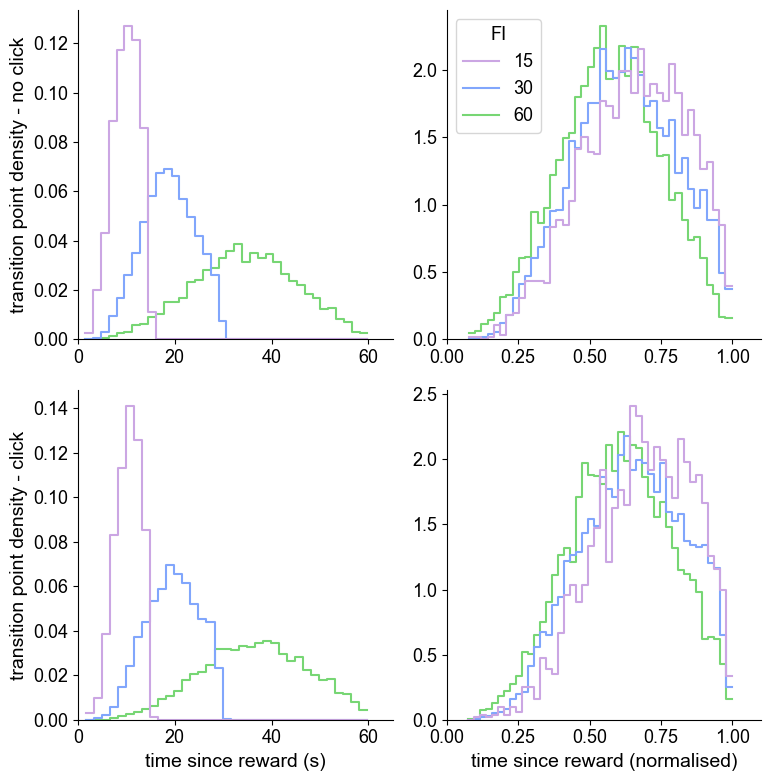

In [64]:
#just to show contraction bias - exp b, with cp corrected
fig, axs = plt.subplots(2,2, figsize = (8,8), tight_layout = True)

sns.histplot(ax = axs[0,0], data = blocksdf.query('click == False and experiment == "b"'), x = 'cp_corrected',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm= False,
    element = 'step', fill = False)
sns.histplot(ax = axs[0,1], data = blocksdf.query('click == False and experiment  == "b"'), x = 'cp_corrected_normalised',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm = False,
    element = 'step', fill = False)#, binwidth = .02)


sns.histplot(ax = axs[1,0], data = blocksdf.query('click == True and experiment == "b"'), x = 'cp_corrected',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm= False,
    element = 'step', fill = False)
sns.histplot(ax = axs[1,1], data = blocksdf.query('click == True and experiment == "b"'), x = 'cp_corrected_normalised',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm = False,
    element = 'step', fill = False)#, binwidth = .02)

    
remove_legend([axs[1,ii] for ii in range(2)])
remove_legend(axs[0,0])

axs[0,0].set_ylabel('transition point density - no click')
axs[1,0].set_ylabel('transition point density - click')

[axs[ii,1].set_ylabel('') for ii in range(2)]

[axs[ii,0].set_xlim(0,65) for ii in range(2)]
[axs[ii,1].set_xlim(0,1.1) for ii in range(2)]

[axs[0,ii].set_xlabel('') for ii in range(2)]

axs[1,0].set_xlabel('time since reward (s)')
axs[1,1].set_xlabel('time since reward (normalised)')

#fig_name = figures.produce_fig_titles('Scalar timing in the transition distributions (corrected) - blocks, experiment b')
#plt.savefig(rf"C:\Users\Utilizador\Documents\git\ratanalysis\analysis_behaviour\figures\cp_blocks\{fig_name}.png", facecolor = 'white')
plt.show()

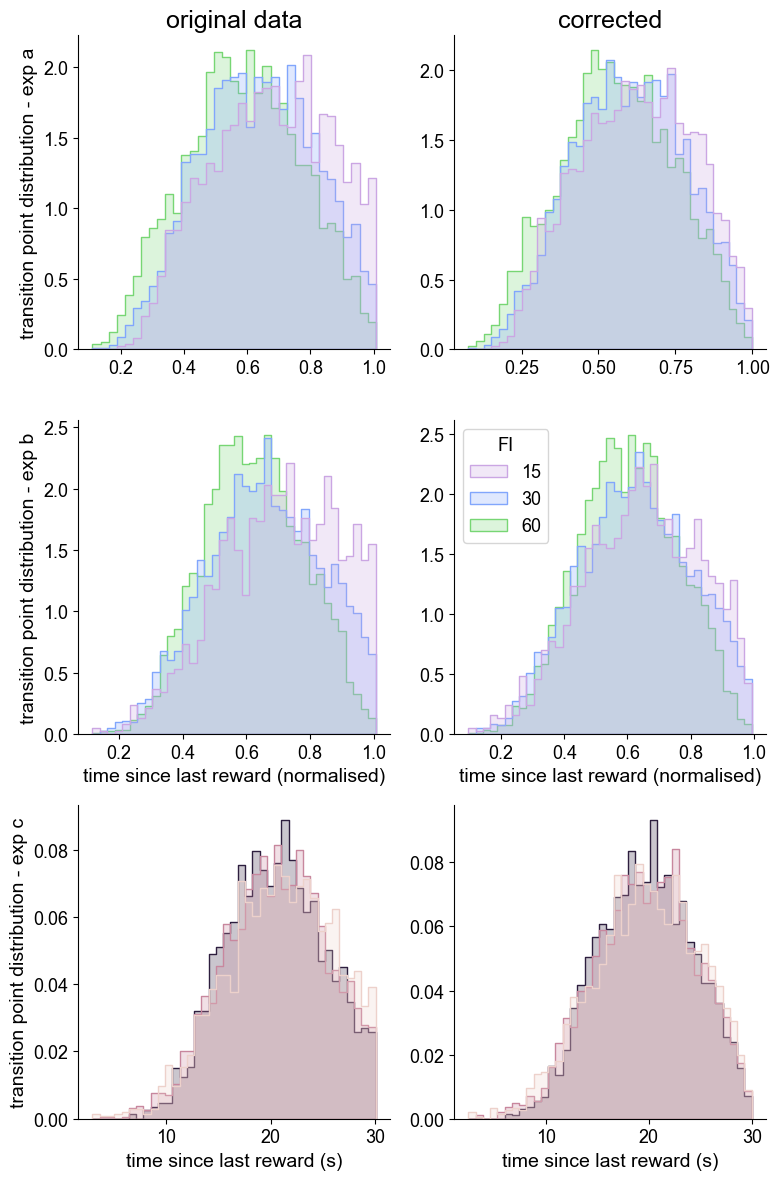

In [65]:
""""
EXP A - In this one, FI is changed but the reward is kept fixed, so there should be a big modulation due
to the differences in pressing rate

EXP B - In this experiment, we keep reward rate constant, which means that the differences in pressing 
rate are minimal and so the correction shouldn't really do much

EXP C - This shows that reward itself doesn't change the transition distribution. In this experiment,
FI is kept fixed and we change reward magnitude. The pressing rate is slightly different and so
we see an effect of later transitions for shoter FIs (consistent with lower pressing rate)
"""

animal_order_blocks_no_click = ['Fluorine', 'Neon', 'Phosphorus', 'Sulfur', 'Potassium', 'Calcium']


fig, axs = plt.subplots(3,2, figsize = (8,12), tight_layout = True)

sns.histplot(ax = axs[0,0], data = blocksdf.query(f'experiment == "a" and animal in {animal_order_blocks_no_click} and bool_steady_state'), x = 'cp_normalised', hue = 'FI',
             fill = True, element = 'step', common_norm=False, stat = 'density',
             hue_order = FI_order, palette = color_FI_blocks)
sns.histplot(ax = axs[0,1], data = blocksdf.query(f'experiment == "a" and animal in {animal_order_blocks_no_click} and bool_steady_state'), x = 'cp_corrected_normalised', hue = 'FI',
             fill = True, element = 'step', common_norm=False, stat = 'density',
             hue_order = FI_order, palette = color_FI_blocks)

sns.histplot(ax = axs[1,0], data = blocksdf.query(f'experiment == "b" and animal in {animal_order_blocks_no_click} and bool_steady_state'), x = 'cp_normalised', hue = 'FI',
             fill = True, element = 'step', common_norm=False, stat = 'density',
             hue_order = FI_order, palette = color_FI_blocks)
sns.histplot(ax = axs[1,1], data = blocksdf.query(f'experiment == "b" and animal in {animal_order_blocks_no_click} and bool_steady_state'), x = 'cp_corrected_normalised', hue = 'FI',
             fill = True, element = 'step', common_norm=False, stat = 'density',
             hue_order = FI_order, palette = color_FI_blocks)

sns.histplot(ax = axs[2,0], data = blocksdf.query(f'experiment == "c" and animal in {animal_order_blocks_no_click} and bool_steady_state'), x = 'cp', hue = 'nprots',
             fill = True, element = 'step', common_norm=False, stat = 'density')
sns.histplot(ax = axs[2,1], data = blocksdf.query(f'experiment == "c" and animal in {animal_order_blocks_no_click} and bool_steady_state'), x = 'cp_corrected', hue = 'nprots',
             fill = True, element = 'step', common_norm=False, stat = 'density')


[axs[0,ii].set_xlabel('') for ii in range(2)]
[axs[1,ii].set_xlabel('time since last reward (normalised)') for ii in range(2)]
[axs[2,ii].set_xlabel('time since last reward (s)') for ii in range(2)]
axs[0,0].set_title('original data')
axs[0,1].set_title('corrected')
axs[0,0].set_ylabel('transition point distribution - exp a')
axs[1,0].set_ylabel('transition point distribution - exp b')
axs[2,0].set_ylabel('transition point distribution - exp c')
[axs[ii,1].set_ylabel('') for ii in range(3)]

#handles, labels = axs[1,1].get_legend_handles_labels()
#axs[1,1].legend(handles, labels, loc='center left', bbox_to_anchor=(1,1))

[remove_legend(axs[jj,ii]) for ii in range(2) for jj in [0,2]]
remove_legend(axs[1,0])

#fig_name = figures.produce_fig_titles('Scalar timing in the blocks transition distributions - correction')
#plt.savefig(rf"C:\Users\Utilizador\Documents\git\ratanalysis\analysis_behaviour\figures\cp_blocks\{fig_name}.png", facecolor = 'white')
plt.show()

c:\Users\Admin\anaconda3\envs\neuro\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


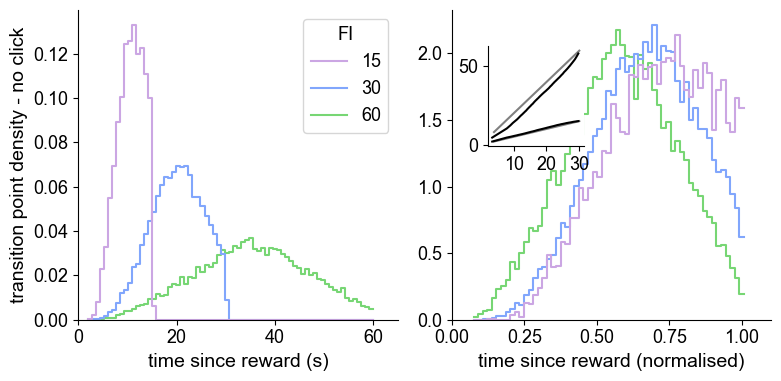

In [66]:
fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True)

sns.histplot(ax = axs[0], data = blocksdf.query('click == False'), x = 'cp',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm= False,
    element = 'step', fill = False)
sns.histplot(ax = axs[1], data = blocksdf.query('click == False'), x = 'cp_normalised',
    hue = 'FI', hue_order = FI_order, palette = color_FI_blocks,
    stat = 'density', common_norm = False,
    element = 'step', fill = False)#, binwidth = .02)


#percentiles inset
axs01_in = inset_axes(axs[1], width = "30%", height = 1, loc = 2, borderpad = 2)
axs01_in.plot([4,30], [8,60], 'grey')
axs01_in.plot(np.quantile(blocksdf.query('click == False and FI == 30').cp.dropna().values, np.arange(0,1,.01)),
         np.quantile(blocksdf.query('click == False and FI == 60').cp.dropna().values, np.arange(0,1,.01)),
         'black')
axs01_in.plot([4,30], [2,15], 'grey')
axs01_in.plot(np.quantile(blocksdf.query('click == False and FI == 30').cp.dropna().values, np.arange(0,1,.01)),
         np.quantile(blocksdf.query('click == False and FI == 15').cp.dropna().values, np.arange(0,1,.01)),
         'black')
axs01_in.set_xlabel('')
axs01_in.set_ylabel('')

remove_legend(axs[1])

axs[0].set_ylabel('transition point density - no click')

axs[1].set_ylabel('')

axs[0].set_xlim(0,65) 
axs[1].set_xlim(0,1.1) 

axs[0].set_xlabel('')

axs[0].set_xlabel('time since reward (s)')
axs[1].set_xlabel('time since reward (normalised)')

#fig_name = figures.produce_fig_titles('Scalar timing in the transition distributions - blocks')

#plt.savefig(fr'{poster_path}/{fig_name}.pdf')#, facecolor = 'white')
plt.show()


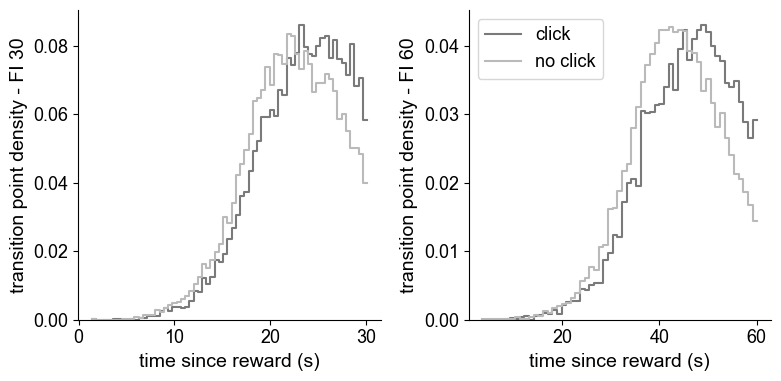

In [67]:

fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True)

sns.histplot(ax = axs[0], data = unidf.query('FI == 30'), x = 'cp', hue = 'click',
             element = 'step', fill = False, stat = 'density', common_norm=False,
            palette=click_palette, hue_order = [False, True])

sns.histplot(ax = axs[1], data = unidf.query('FI == 60'), x = 'cp', hue = 'click',
             element = 'step', fill = False, stat = 'density', common_norm=False,
            palette=click_palette, hue_order=[False, True])

axs[0].set_ylabel('transition point density - FI 30')
axs[1].set_ylabel('transition point density - FI 60')

[axs[ii].set_xlabel('time since reward (s)') for ii in range(2)]

remove_legend(axs[0])
plt.legend(labels = ['click', 'no click'])

#fig_name = figures.produce_fig_titles('Click on transition point')

#plt.savefig(fr'{fig_path}/{fig_name}.png', facecolor = 'white')
plt.show()

## pressing rate and rwd rate

Presssing rate after the transition point, a la elife style. Do separately for click and no click animals, and start by unidf only.
Is it true that animals with click are affected differently withe the reward / reward rate??

Ok, here's something super relevant!! I should be dividing by the number of trials that are not over yet, for all points of time. So my approach will actually be to compute the matrix and then use that! :)

from elife: Average rate of lever pressing in each block, aligned on PST. Traces are plotted on a solid line for the period for which more than half of the trials contribute data and on a dotted line after that point. Shaded patches along the horizontal axis represent SEM. 1 s bins

In [72]:
exp_list = ['a', 'b', 'c']
click_order = [False, True]

NameError: name 'get_lever_press_matrix' is not defined

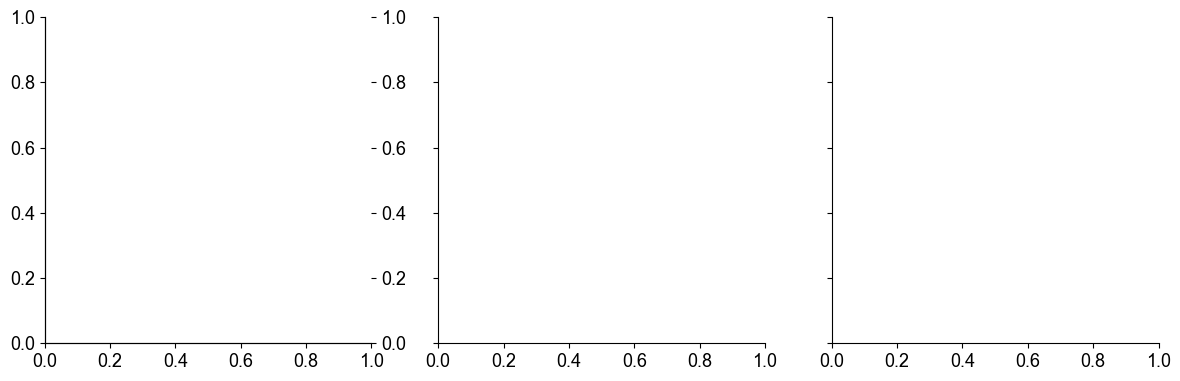

In [70]:
## run both click and no click plots with this cell

fig, axs = plt.subplots(1,3, figsize = (12,4), tight_layout = True, sharex = True, sharey = True)

click = False
click_label = 'click' if click else 'no click'
rwd_labels = ['small', 'interm', 'large']
for jj in range(3):
    exp = exp_list[jj]

    twin_ax = axs[jj].twinx()

    for ii in range(3):
        if exp == "c":
            n_prots = rwd_order[ii]
            _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(blocksdf.query(f'click == {click} and experiment == "{exp}" and n_protocols == {n_prots} and bool_cp and count_lever > 3'), [-3,12], bin_width=.2)
            axs[jj].plot(bins[frac_finished_trials<=0.5], mean_rate[frac_finished_trials<=0.5], color = color_rwd_blocks[ii], label = rwd_labels[ii])
            axs[jj].plot(bins[frac_finished_trials>0.5], mean_rate[frac_finished_trials>0.5], color = color_rwd_blocks[ii],ls = 'dotted')
                        
            twin_ax.fill_between(bins,np.zeros(len(SEM)), SEM, color=color_rwd_blocks[ii], alpha = 0.5)

        else:
            FI = FI_order[ii]
            _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(blocksdf.query(f'click == {click} and experiment == "{exp}" and FI == {FI} and bool_cp and count_lever > 3'),[-3,12],bin_width=.2)
            axs[jj].plot(bins[frac_finished_trials<=0.5], mean_rate[frac_finished_trials<=0.5], color = color_FI_blocks[ii], label = f'FI{FI}')
            axs[jj].plot(bins[frac_finished_trials>0.5], mean_rate[frac_finished_trials>0.5], color = color_FI_blocks[ii],ls = 'dotted')

            twin_ax.fill_between(bins,np.zeros(len(SEM)), SEM, color=color_FI_blocks[ii], alpha = 0.5)
    
    twin_ax.tick_params(axis='y', labelcolor='grey')
    twin_ax.set_ylim(0,.4)

    axs[jj].set_xlabel('time since transition (s)')

axs[0].set_title('varying FI')
axs[1].set_title('fixed reward rate')
axs[2].set_title('varying reward magnitude')

axs[0].set_ylabel('pressing rate (Hz)')
axs[0].set_ylim(0)

twin_ax.set_ylabel('SEM', color='grey')


axs[0].legend(
    ncol=1,
    loc='upper center',
    handlelength=1,
    handletextpad=0.7,
    columnspacing=1,
    bbox_to_anchor=(0.75, 0.45),  # (x, y) where y is negative for below the axes
    frameon=False
)

axs[2].legend(
    ncol=1,
    loc='upper center',
    handlelength=1,
    handletextpad=0.7,
    columnspacing=1,
    bbox_to_anchor=(0.75, 0.45),  # (x, y) where y is negative for below the axes
    frameon=False
)

figtitle = f'Pressing rate across different reward rate manipulations in block sessions | {click_label}'
plt.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}_nolegends.pdf')


NameError: name 'get_lever_press_matrix' is not defined

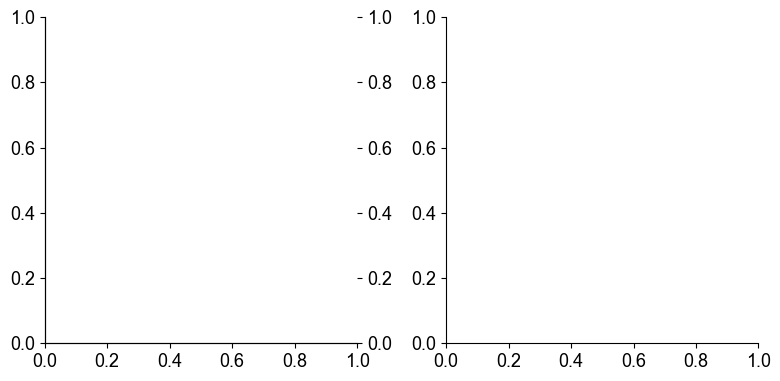

In [73]:
fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True, sharex = True, sharey = False)

for jj in range(2):
    click = click_order[jj]

    twin_ax = axs[jj].twinx()


    for ii in range(1,3):
        FI = FI_order[ii]

        #small reward
        _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(unidf.query(f'click == {click} and FI == {FI} and n_protocols == 15 and bool_cp and count_lever > 3 and batch != "batch1"'),[-3,12],bin_width=.2)
        axs[jj].plot(bins[frac_finished_trials<=0.5], mean_rate[frac_finished_trials<=0.5], color = color_FI_blocks[ii], ls = 'dashed', label = f'FI{FI} small')
        axs[jj].plot(bins[frac_finished_trials>0.5], mean_rate[frac_finished_trials>0.5], color = color_FI_blocks[ii],ls = 'dotted')

        twin_ax.fill_between(bins,np.zeros(len(SEM)), SEM, color=color_FI_blocks[ii], alpha = 0.5)

        #big reward
        _, bins, mean_rate, SEM, frac_finished_trials = get_lever_press_matrix(unidf.query(f'click == {click} and FI == {FI} and n_protocols == 30 and bool_cp and count_lever > 3 and batch != "batch1"'),[-3,12],bin_width=.2)
        axs[jj].plot(bins[frac_finished_trials<=0.5], mean_rate[frac_finished_trials<=0.5], color = color_FI_blocks[ii], label = f'FI{FI} big')
        axs[jj].plot(bins[frac_finished_trials>0.5], mean_rate[frac_finished_trials>0.5], color = color_FI_blocks[ii],ls = 'dotted')

        twin_ax.fill_between(bins,np.zeros(len(SEM)), SEM, color=color_FI_blocks[ii], alpha = 0.5)
        
    twin_ax.set_ylim(0,.4)
    twin_ax.tick_params(axis='y', labelcolor='grey')



axs[0].legend(
    ncol=1,
    loc='upper center',
    handlelength=1,
    handletextpad=0.7,
    columnspacing=1,
    bbox_to_anchor=(0.75, 0.50),  # (x, y) where y is negative for below the axes
    frameon=False
)

axs[0].set_ylim(0)
axs[1].set_ylim(0)
axs[0].set_title('no click')
axs[1].set_title('click')

axs[0].set_ylabel('pressing rate (Hz)')

twin_ax.set_ylabel('SEM', color='grey')

figtitle = f'Pressing rate across different single-condition sessions'
plt.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')

rateH is computed as:
count of lever presses after the transition point, including transition point press, up until the last press (after FI)

I confirmed this by looking at presses aligned to cp, counting them (and +1 because of the cp) and dividing by the value of the last press aligned (time elapsed since cp). The difference between doing this or the average of the step function (after transition) is that the latter doesn't include the cp press 

I could see a scenario in which I would exclude cp press, but for now this is it

In [74]:
df = unidf.query('bool_cp and count_lever > 3 and batch != "batch1" and n_protocols in [15,30]').groupby('animaldate').agg({
    'animal': 'first',
    'date': 'first',
    'FI': 'first',
    'n_protocols': 'first',
    'click': 'first',
    'rateH': list
}).reset_index()

In [75]:
df['rateH_av'] = df.rateH.apply(lambda x: np.mean(x))
df['nprots_label'] = df.n_protocols.apply(lambda x: 'big' if x == 30 else 'small')
df['FI_nprots'] = df.apply(lambda x: f'FI{x.FI} {x.nprots_label}', axis = 1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\1169298050.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='FI_nprots', ylabel='rateH_av'>

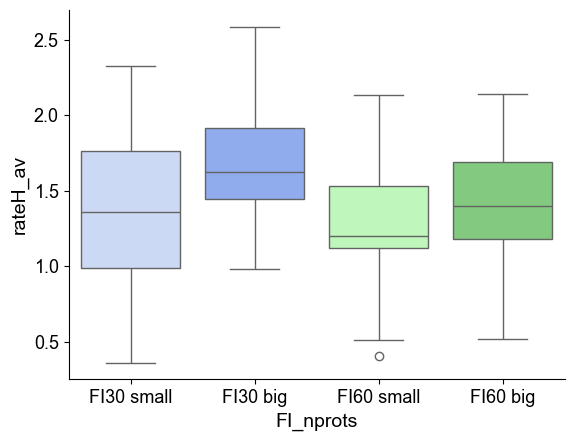

In [76]:
sns.boxplot(
    data=df.query('click == False'),
    x='FI_nprots',
    y='rateH_av',
    order=['FI30 small', 'FI30 big', 'FI60 small', 'FI60 big'],
    palette=['#c5d6fc', color_FI_blocks[1], '#b5ffb3' , color_FI_blocks[2]]
)

In [77]:
eg_animals = ['Boron', 'Carbon','Nitrogen', 'Oxygen']
n_days = 15
dates_0 = list(df.query(f'animal == "{eg_animals[0]}"').date.values[12:12+n_days])
dates_1 = list(df.query(f'animal == "{eg_animals[1]}"').date.values[20:20+n_days])
dates_2 = list(df.query(f'animal == "{eg_animals[2]}"').date.values[10:10+n_days])
dates_3 = list(df.query(f'animal == "{eg_animals[3]}"').date.values[15:15+n_days])

dates = [dates_0,dates_1,dates_2,dates_3]

Text(0.5, 0, 'sessions')

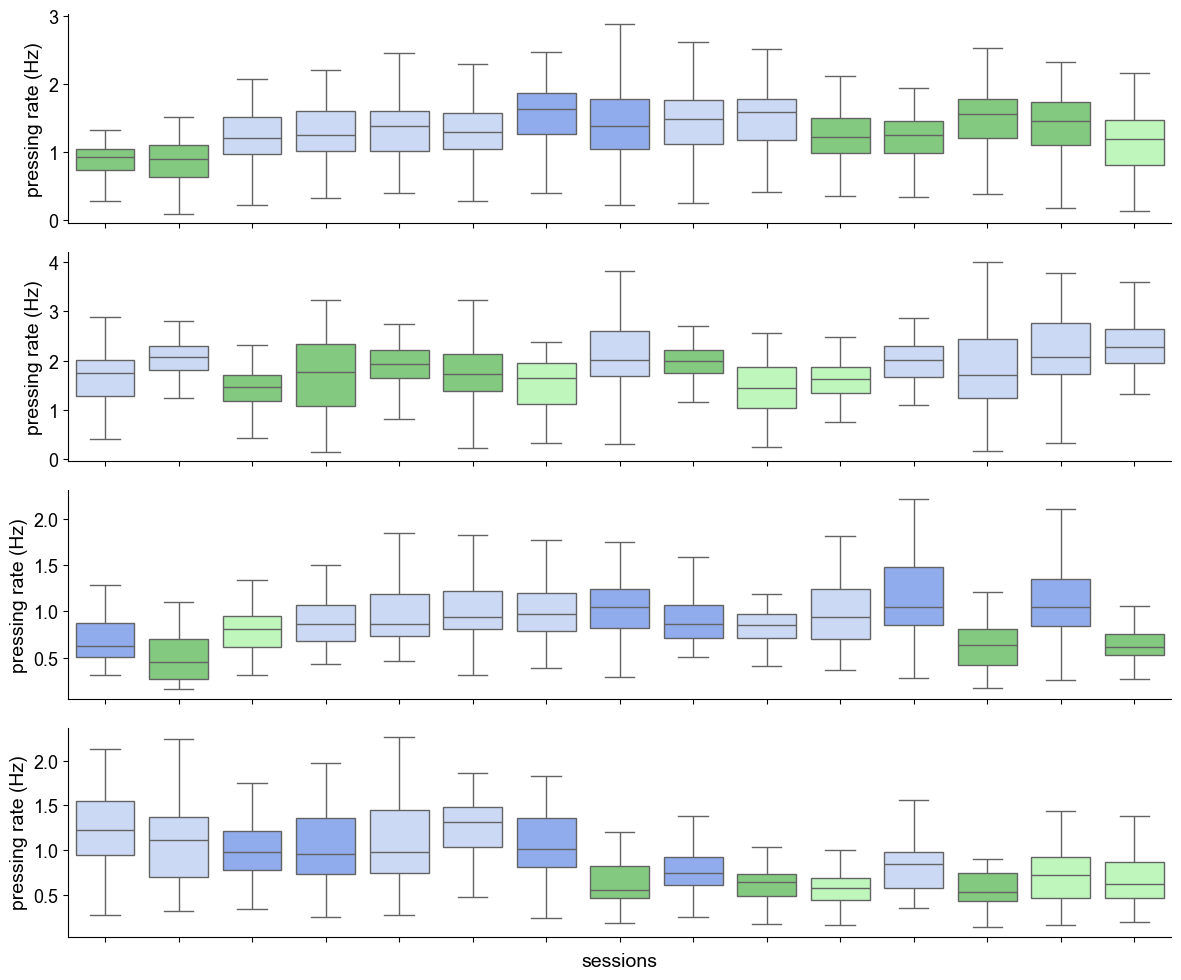

In [78]:
fig, axs = plt.subplots(4, figsize = (12,10), tight_layout = True)


for ii in range(4):
    animal = eg_animals[ii]
    sns.boxplot(ax = axs[ii], data = df.query(f'animal == "{animal}" and date in {dates[ii]}').explode('rateH'), x = 'date', y = 'rateH', hue = 'FI_nprots', showfliers = False,
                hue_order=['FI30 small', 'FI30 big', 'FI60 small', 'FI60 big'],
                palette=['#c5d6fc', color_FI_blocks[1], '#b5ffb3' , color_FI_blocks[2]])
    axs[ii].legend_.remove()
    axs[ii].set_xticklabels([])
    axs[ii].set_xlabel('')

    axs[ii].set_ylabel('pressing rate (Hz)')

axs[-1].set_xlabel('sessions')

Text(0.5, 0.98, 'Pressing rate in two example animals in single-condition sessions')

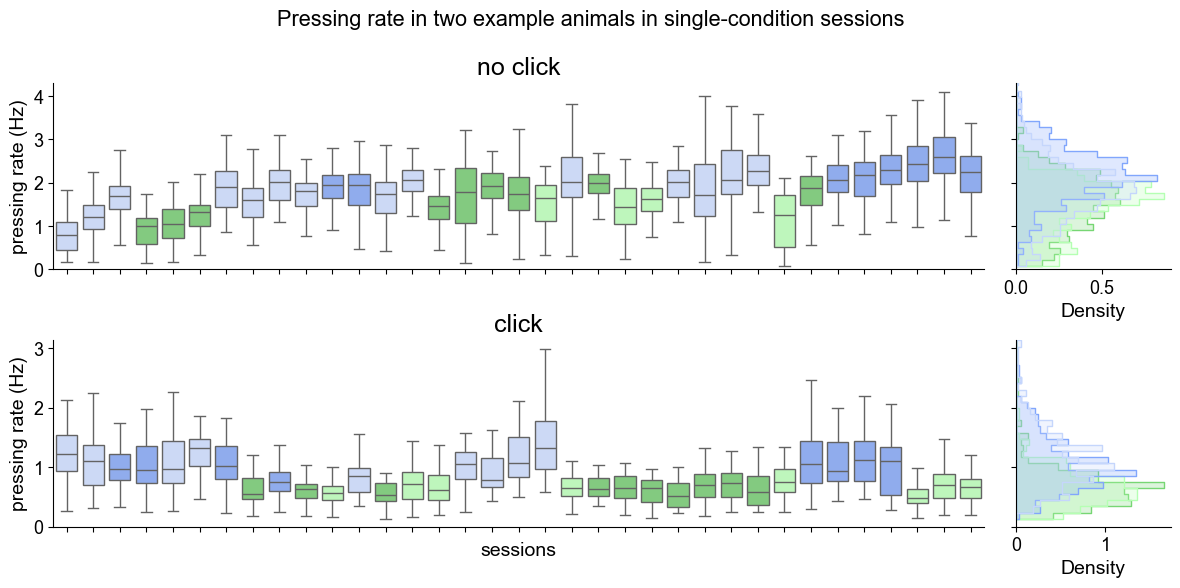

In [79]:
eg_animals = ['Carbon','Oxygen']
n_days = 35
dates_1 = list(df.query(f'animal == "{eg_animals[0]}"').date.values[8:8+n_days])
dates_2 = list(df.query(f'animal == "{eg_animals[1]}"').date.values[15:15+n_days])

dates = [dates_1,dates_2]


fig, axs = plt.subplots(2,2, figsize = (12,6), tight_layout = True, sharey = 'row', width_ratios=[6,1])


for ii in range(2):
    animal = eg_animals[ii]
    sns.boxplot(ax = axs[ii,0], data = df.query(f'animal == "{animal}" and date in {dates[ii]}').explode('rateH'), x = 'date', y = 'rateH', hue = 'FI_nprots', showfliers = False,
                hue_order=['FI30 small', 'FI30 big', 'FI60 small', 'FI60 big'],
                palette=['#c5d6fc', color_FI_blocks[1], '#b5ffb3' , color_FI_blocks[2]])
    axs[ii,0].legend_.remove()
    axs[ii,0].set_xticklabels([])
    axs[ii,0].set_xlabel('')

    axs[ii,0].set_ylabel('pressing rate (Hz)')
    axs[ii,0].set_ylim(0)

    sns.histplot(ax = axs[ii,1], data = df.query(f'animal == "{animal}" and date in {dates[ii]}').explode('rateH'),
                 y = 'rateH', hue = 'FI_nprots', stat = 'density', common_norm=False, element = 'step',
                 hue_order=['FI30 small', 'FI30 big', 'FI60 small', 'FI60 big'],
                palette=['#c5d6fc', color_FI_blocks[1], '#b5ffb3' , color_FI_blocks[2]])

    #sns.histplot(ax = axs[ii,1], data = df.query(f'animal == "{animal}" and date in {dates[ii]}'),
    #             y = 'rateH_av', hue = 'FI_nprots', stat = 'density', common_norm=False, element = 'step',
    #             hue_order=['FI30 small', 'FI30 big', 'FI60 small', 'FI60 big'],
    #            palette=['#c5d6fc', color_FI_blocks[1], '#b5ffb3' , color_FI_blocks[2]])

    axs[ii,1].legend_.remove()


axs[-1,0].set_xlabel('sessions')
axs[0,0].set_title('no click')
axs[1,0].set_title('click')



figtitle = 'Pressing rate in two example animals in single-condition sessions'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')

## instantaneous rwd rate @ cp

the goal of this is to show that animals track local rwd rate, and that small differences in rwd rate, even in matched rwd rate sessions, are associated to differences in pressing rate. It would also be cool to show that reward rate does not influence the transition point (corrected transition point).

In [80]:
def add_exp_reward_rate_per_session(df, time_col='last_lever_abs', amp_col='nprots',
                                    dt=0.1, half_life=60.0,
                                    t_start=0.0, trial_len_col=None, t_end=None):
    """
    Adds local reward rate using a causal exponential kernel:
      y[t] = alpha * y[t-1] + x[t],  alpha = exp(-dt/tau),  tau = half_life / ln(2)

    Inputs:
      - df: per-session DataFrame
      - time_col: list/array of reward times (seconds)
      - amp_col:  list/array of magnitudes (same length as time_col)
      - dt: bin size in seconds (0.1 s = 100 ms)
      - half_life: seconds for y to halve with no new rewards (e.g., 60 s)
      - t_start: usually 0.0
      - trial_len_col: if present, fixes each session duration (e.g., 15/30/60)
      - t_end: optional global end time override (seconds)

    Returns: copy of df with 't', 't_s', 'reward_rate' columns (arrays)
    """
    tau = half_life / np.log(2.0)
    alpha = float(np.exp(-dt / tau))

    t_list, rate_list = [], []
    for _, row in df.iterrows():
        # Determine end time for this session
        if trial_len_col is not None and pd.notna(row[trial_len_col]):
            this_t_end = float(t_start) + float(row[trial_len_col])
        else:
            # extend a bit beyond last event so you see the decay if no trial_len
            times = np.asarray(row[time_col], dtype=float)
            times = times[np.isfinite(times)]
            last_event = float(times.max()) if times.size else 0.0
            this_t_end = float(t_end) if t_end is not None else last_event

        # Build time grid
        t = np.arange(t_start, this_t_end + 1e-12, dt)
        n = t.size
        x = np.zeros(n, dtype=float)

        # Bin impulses
        times = np.asarray(row[time_col], dtype=float)
        amps  = np.asarray(row[amp_col],  dtype=float)
        m = np.isfinite(times) & np.isfinite(amps)
        times, amps = times[m], amps[m]

        if times.size:
            idx = np.rint((times - t_start) / dt).astype(int)
            valid = (idx >= 0) & (idx < n)
            np.add.at(x, idx[valid], amps[valid])

        # Exponential IIR (causal)
        y = np.empty(n, dtype=float)
        acc = 0.0
        for i in range(n):
            acc = alpha * acc + x[i]
            y[i] = acc

        t_list.append(t)
        rate_list.append(y)

    out = df.copy()
    out['t'] = t_list               # bin indices in seconds already (since grid is 0..T in steps of dt)
    out['t_s'] = out['t']           # explicit alias: time in seconds
    out['reward_rate'] = rate_list  # local reward rate
    return out



def sample_reward_rate_at_times(t, y, query_times, method="linear"):
    """
    t: 1D array of time (seconds), length N
    y: 1D array of reward_rate, length N
    query_times: list/array of timestamps (seconds) to sample at
    method: "linear" or "nearest"
    Returns: list of sampled values aligned to query_times (NaN for NaN/out-of-range)
    """
    if query_times is None:
        return []
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    q = np.asarray(query_times, dtype=float)

    out = np.full_like(q, np.nan, dtype=float)
    finite = np.isfinite(q)
    if not np.any(finite) or t.size == 0:
        return out.tolist()

    if method == "linear":
        # Linear interpolation; outside [t.min, t.max] stays NaN
        qf = q[finite]
        in_range = (qf >= t[0]) & (qf <= t[-1])
        out_idx = np.where(finite)[0]
        # only interpolate those within range
        out[out_idx[in_range]] = np.interp(qf[in_range], t, y)
        # out-of-range remain NaN
    elif method == "nearest":
        # Nearest-bin lookup
        dt_est = np.median(np.diff(t)) if t.size > 1 else np.nan
        if not np.isfinite(dt_est) or dt_est <= 0:
            return out.tolist()
        idx = np.rint((q[finite] - t[0]) / dt_est).astype(int)
        valid = (idx >= 0) & (idx < y.size)
        out_finite_idx = np.where(finite)[0]
        out[out_finite_idx[valid]] = y[idx[valid]]
    else:
        raise ValueError("method must be 'linear' or 'nearest'")

    return out.tolist()

def collect_events(series):
    vals = []
    # drop NaNs first
    for v in series.dropna():
        # flatten if the cell already contains a list/array/Series
        if isinstance(v, (list, tuple, np.ndarray, pd.Series)):
            vals.extend(np.ravel(v).tolist())
        else:
            vals.append(v)
    # sort and return as a plain Python list
    return sorted(vals)

In [81]:
def add_discounted_reward_rate_per_session(
    df,
    time_col='last_lever_abs',
    amp_col='nprots',
    dt=0.1,
    half_life=60.0,
    t_start=0.0,
    trial_len_col=None,
    t_end=None,
    discount='hyperbolic',     # 'hyperbolic' or 'exponential'
    s=1.0                      # hyperbolic shape (s=1 => Mazur)
):
    """
    Adds a discounted (convolved) reward-rate signal per row using either
    exponential (memoryless) or hyperbolic (present-biased) discounting.

    Output columns:
      - 't' (seconds), 't_s' (alias), 'reward_rate' (array)

    Parameters
    ----------
    df : DataFrame (one row per session/block)
    time_col : iterable of reward times (seconds)
    amp_col  : iterable of impulse amplitudes (use np.log(mag) here if desired)
    dt : bin size (s)
    half_life : half-life of discount (s)
    t_start : start time (s)
    trial_len_col : optional per-row duration (s)
    t_end : optional fixed end time (s) if no trial_len_col
    discount : 'exponential' or 'hyperbolic'
    s : hyperbolic shape parameter (>=1 recommended; s=1 is classic Mazur)

    Notes
    -----
    - Exponential kernel (unit area):
        y[i] = alpha * y[i-1] + x[i],  alpha = exp(-dt/tau),  tau = half_life/ln(2)
        x has impulses scaled by (amp / tau) at the event bin.
    - Hyperbolic kernel:
        w(t) = c0 / (1 + k t)^s,  with k = (2**(1/s) - 1)/half_life.
        By default c0 = 1/tau so w(0) matches exp kernel's initial height.
        (Area diverges for s<=1 over infinite horizon; over finite sessions this is fine.)
    """
    # Shared constants
    tau = float(half_life / np.log(2.0))          # exponential time constant
    t_list, rate_list = [], []

    # Precompute hyperbolic kernel builder
    if discount.lower().startswith('hyp'):
        # Convert half-life to k via D(t_half)=1/2
        k = (2.0**(1.0 / s) - 1.0) / float(half_life)
        c0 = 1.0 / tau  # match initial height to exp kernel
    else:
        k = None
        c0 = None

    for _, row in df.iterrows():
        # --- determine end time for this row
        if trial_len_col is not None and pd.notna(row[trial_len_col]):
            this_t_end = float(t_start) + float(row[trial_len_col])
        else:
            times_raw = np.asarray(row[time_col], dtype=float)
            times_raw = times_raw[np.isfinite(times_raw)]
            last_event = float(times_raw.max()) if times_raw.size else 0.0
            this_t_end = float(t_end) if t_end is not None else last_event

        # --- build time grid
        t = np.arange(t_start, this_t_end + 1e-12, dt)
        n = t.size

        # --- collect events
        times = np.asarray(row[time_col], dtype=float)
        amps  = np.asarray(row[amp_col],  dtype=float)
        m = np.isfinite(times) & np.isfinite(amps)
        times, amps = times[m], amps[m]

        # --- left-edge binning of impulses
        idx = np.floor((times - t_start) / dt).astype(int) if times.size else np.array([], dtype=int)
        valid = (idx >= 0) & (idx < n)
        idx, amps = idx[valid], amps[valid]

        if discount.lower().startswith('exp'):
            # ========= Exponential (unit-area) =========
            alpha = float(np.exp(-dt / tau))
            x = np.zeros(n, dtype=float)
            if idx.size:
                # unit-area kernel for delta inputs: add amp / tau at the event bin
                np.add.at(x, idx, amps / tau)

            y = np.empty(n, dtype=float)
            acc = 0.0
            for i in range(n):
                acc = alpha * acc + x[i]
                y[i] = acc

        else:
            # ========= Hyperbolic =========
            # Build causal kernel values up to horizon n
            lags = np.arange(n, dtype=float) * dt
            w = c0 / (1.0 + k * lags)**s  # w[0] = c0 = 1/tau

            # Convolve by adding each event's shifted kernel (efficient & exact)
            y = np.zeros(n, dtype=float)
            for j, a in zip(idx, amps):
                # add a * w shifted by j
                L = n - j
                if L > 0:
                    y[j:] += a * w[:L]

        t_list.append(t)
        rate_list.append(y)

    out = df.copy()
    out['t'] = t_list
    out['t_s'] = out['t']
    out['reward_rate'] = rate_list
    return out


In [82]:
blocksdf['last_press_abs'] = blocksdf.lever_abs.apply(lambda x: x[-1]/1000)
blocksdf['cp_abs'] = blocksdf.apply(lambda x: x.trial_start/1000 + x.cp, axis = 1)
blocksdf['cp_corrected_abs'] = blocksdf.apply(lambda x: x.trial_start/1000 + x.cp_corrected, axis = 1)

In [83]:
df_session_events = (
    blocksdf.query('click == False').groupby('animaldate', as_index=False)
      .agg(
          last_lever_abs=('last_press_abs', collect_events),
          cp_abs=('cp_abs', collect_events),
          nprots=('nprots', collect_events),
          FI=('FI', collect_events),
          bool_cp = ('bool_cp', collect_events),
          cp_corrected_abs = ('cp_corrected_abs', collect_events),
      )
)

In [84]:
df_session_events['nprots_log'] = df_session_events.nprots.apply(lambda x: np.log(x))

impulses_rateH_c = np.log(np.array(rateH_c)/rateH_c[1])

dict_impulses_rate = dict(zip(nprots_list,[1,1,1]))

df_session_events['nprots_softmax'] = df_session_events.nprots.apply(lambda x: [dict_impulses_rate[val] for val in x])

NameError: name 'rateH_c' is not defined

In [85]:
half_life = 35*np.log(2)

df_conv = add_exp_reward_rate_per_session(
    df_session_events,
    time_col='last_lever_abs',
    amp_col='nprots_softmax',   # (apply your *10 scaling beforehand if desired)
    dt=0.1,
    half_life=half_life,
    t_start=0.0,
    trial_len_col=None  # 15 / 30 / 60 per session
)


KeyError: 'nprots_softmax'

In [86]:
df_conv.query('experiment == "c"')

NameError: name 'df_conv' is not defined

all of tis part is a mess, go revisit thesis code (this wasn't resolved before submitting the thesis)

## Proportion of transition trials

As a function of reward rate. DO it for unidf and blocksdf

In [87]:
propdf = unidf.query('batch != "batch1" and n_protocols in [15,30]').groupby('animaldate').agg({
    'animal': 'first',
    'date': 'first',
    'FI': 'first',
    'n_protocols': 'first',
    'click': 'first',
    'proportion_cp': 'first'
}).reset_index()

propdf['nprots_label'] = propdf.n_protocols.apply(lambda x: 'big' if x == 30 else 'small')
propdf['FI_nprots'] = propdf.apply(lambda x: f'FI{x.FI} {x.nprots_label}', axis = 1)

In [88]:
propblocksdf = blocksdf.groupby('blockno').agg({
    'animaldate': 'first',
    'animal': 'first',
    'date': 'first',
    'experiment': 'first',
    'FI': 'first',
    'n_protocols': 'first',
    'click': 'first',
    'bool_cp': list
}).reset_index()

propblocksdf['prop_cp'] = propblocksdf.bool_cp.apply(lambda x: sum(x) / len(x))
#propdf['nprots_label'] = propdf.n_protocols.apply(lambda x: 'big' if x == 30 else 'small')
#propblocksdf['FI_nprots'] = propblocksdf.apply(lambda x: f'FI{x.FI} {x.nprots_label}', axis = 1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\3753463226.py:3: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(ax = axs[0,0], data = propdf.query('click == False'),
C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\3753463226.py:13: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(ax = axs[1,0], data = propdf.query('click == True'),
C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\3753463226.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax = axs[0,1+ii], data = propblocksdf.query(f'experiment == "{exp}" and click == {click}'),
C:\Users\Admin\AppData\Local\Temp\ipykernel_30880\3753463226.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

NameError: name 'color_nprots_blocks' is not defined

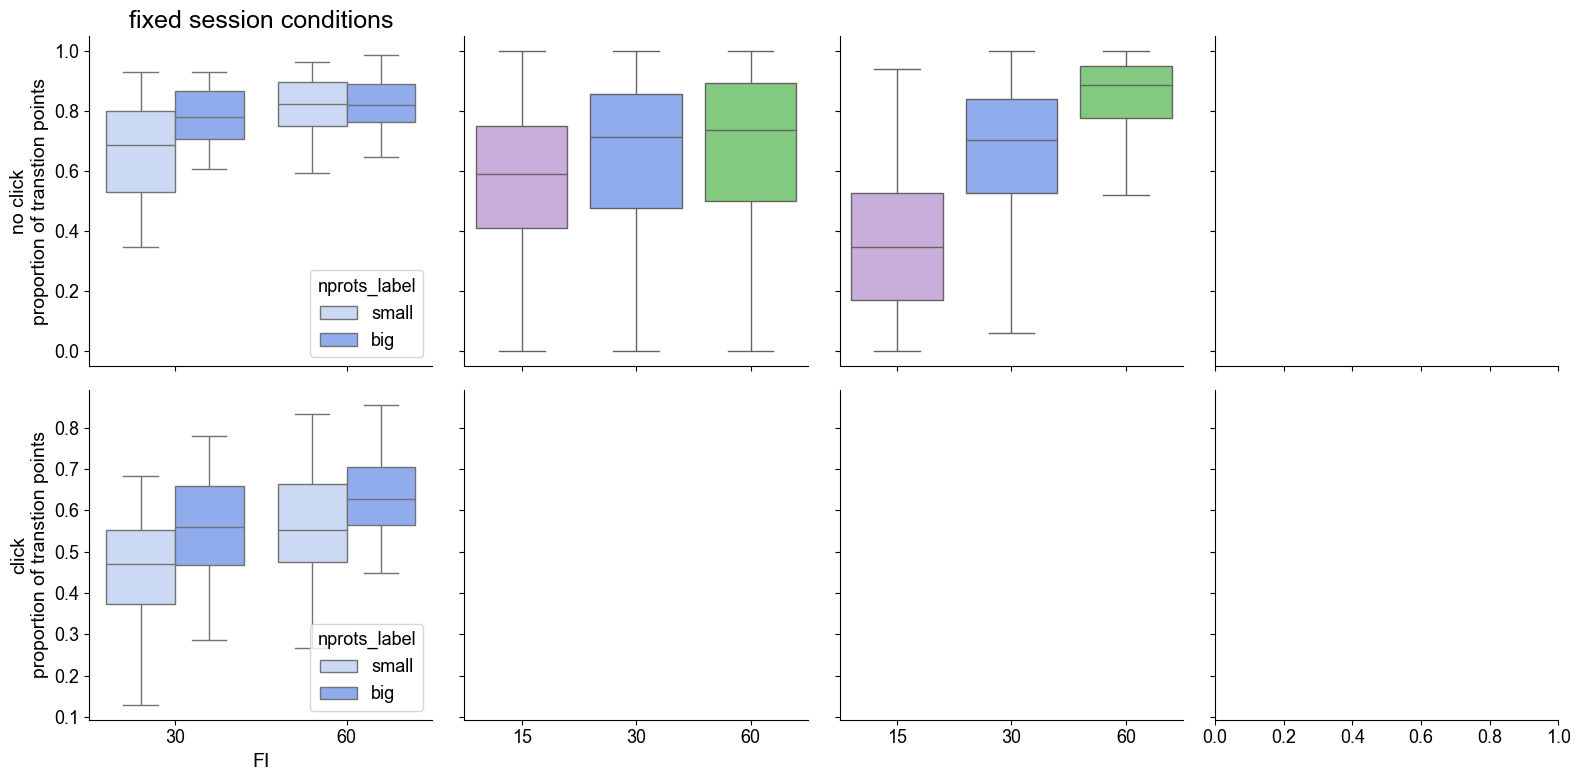

In [ ]:
fig, axs = plt.subplots(2,4, figsize = (16,8), tight_layout = True, sharey = 'row', sharex = 'col')

sns.boxplot(ax = axs[0,0], data = propdf.query('click == False'),
    x ='FI',
    hue = 'nprots_label',
    y='proportion_cp',
    #hue_order=['FI30 small', 'FI30 big', 'FI60 small', 'FI60 big'],
    palette=['#c5d6fc', color_FI_blocks[1], '#b5ffb3' , color_FI_blocks[2]],
    #palette = color_FI_blocks[1:],
    showfliers = False
)

sns.boxplot(ax = axs[1,0], data = propdf.query('click == True'),
    x ='FI',
    hue = 'nprots_label',
    #x='FI_nprots',
    y='proportion_cp',
    #order=['FI30 small', 'FI30 big', 'FI60 small', 'FI60 big'],
    palette=['#c5d6fc', color_FI_blocks[1], '#b5ffb3' , color_FI_blocks[2]],
    showfliers = False
)


axs[0,0].set_title('fixed session conditions')
axs[1,0].set_xlabel('FI')#-reward pairings')

axs[0,0].set_ylabel('no click\nproportion of transtion points')
axs[1,0].set_ylabel('click\nproportion of transtion points')



click = False 
for ii in range(2):
    exp = exp_list[ii]
    sns.boxplot(ax = axs[0,1+ii], data = propblocksdf.query(f'experiment == "{exp}" and click == {click}'),
            x = 'FI', y = 'prop_cp', showfliers = False,
            palette=color_FI_blocks)
    
## exp c
sns.boxplot(ax = axs[0,-1], data = propblocksdf.query(f'experiment == "c" and n_protocols in [7,14,28] and click == {click}'),
            x = 'FI', hue = 'n_protocols', y = 'prop_cp', showfliers = False,
            palette=color_rwd_blocks)



click = True 
for ii in range(2):
    exp = exp_list[ii]
    sns.boxplot(ax = axs[1,1+ii], data = propblocksdf.query(f'experiment == "{exp}" and click == {click}'),
            x = 'FI', y = 'prop_cp', showfliers = False,
            palette=color_FI_blocks)
    
## exp c
sns.boxplot(ax = axs[1,-1], data = propblocksdf.query(f'experiment == "c" and n_protocols in [7,14,28] and click == {click}'),
            x = 'FI', hue = 'n_protocols', y = 'prop_cp', showfliers = False,
            palette=color_rwd_blocks)

median_propcp_noclick = np.nanmedian(
    np.hstack([
        propdf.query('click == False').proportion_cp.values,
        propblocksdf.query('click == False').prop_cp.values]))

median_propcp_click = np.nanmedian(
    np.hstack([
        propdf.query('click == True').proportion_cp.values,
        propblocksdf.query('click == True').prop_cp.values]))

for ii in range(4):
    axs[0,ii].axhline(median_propcp_noclick, color = 'grey', ls = '--',zorder = 1)
    axs[1,ii].axhline(median_propcp_click, color = 'grey', ls = '--', zorder = 1)

axs[0, -1].text(1.01, median_propcp_noclick-.02, np.round(median_propcp_noclick,2), transform=axs[0, -1].transAxes,
               fontsize=14, va="center", ha="left")
axs[1, -1].text(1.01, median_propcp_click, np.round(median_propcp_click,2), transform=axs[1, -1].transAxes,
               fontsize=14, va="center", ha="left")


for ii in range(2):
    remove_legend(axs[ii,0])
    remove_legend(axs[ii,-1])


axs[0,1].set_title('varying FI')
axs[0,2].set_title('fixed reward rate')
axs[0,3].set_title('varying reward magnitude')

figtitle = f'proportion of transition trials across all experimental conditions'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.pdf')



In [90]:
for animal in blocksdf.animal.unique():
    print(f'{animal} {len(blocksdf.query(f'animal == "{animal}"').animaldate.unique())}')

Argon 97
Calcium 87
Chlorine 95
Fluorine 34
Krypton 27
Magnesium 37
Neon 38
Niobium 29
Phosphorus 98
Potassium 85
Rubidium 46
Scandium 86
Selenium 32
Sodium 28
Strontium 66
Sulfur 99
Technetium 31
Titanium 83
Yttrium 45
Zirconium 89


## cp and rateH independent

Text(0.5, 0.98, 'joint distribution of transition point and reward rate')

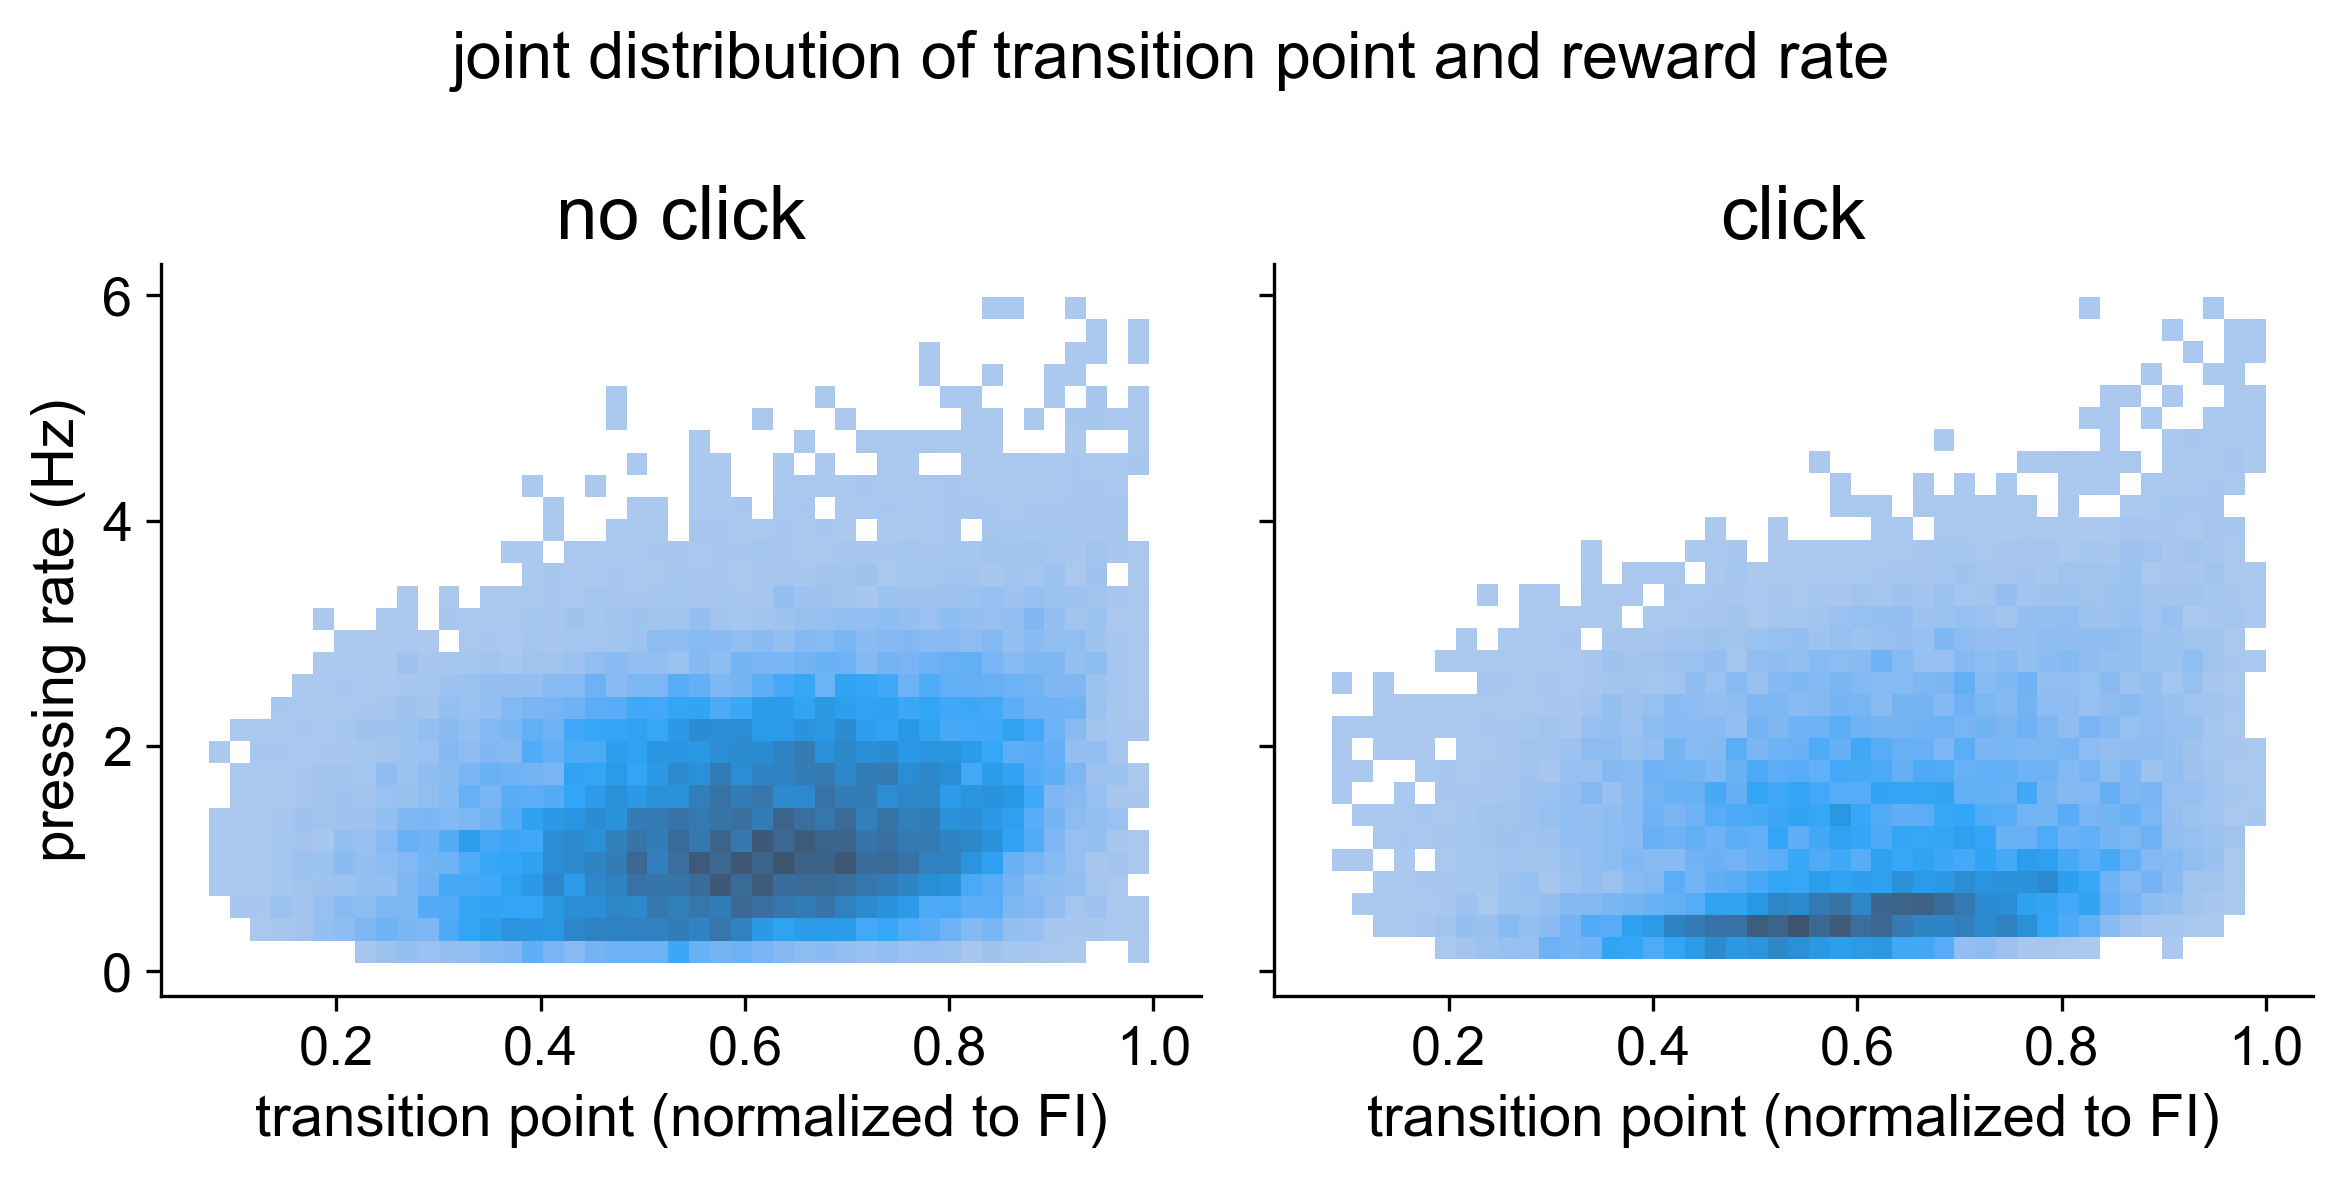

In [92]:
fig, axs = plt.subplots(1,2, figsize = (8,4), tight_layout = True, sharey=True, sharex = True, dpi = 300)
sns.histplot(ax= axs[0], data = blocksdf.query('click == False and bool_cp and cp_normalised < 1 and count_lever > 5 and rateH < 6'),
             x = 'cp_normalised', y = 'rateH', bins=(45,30))
sns.histplot(ax= axs[1], data = blocksdf.query('click == True and bool_cp and cp_normalised < 1 and count_lever > 5 and rateH < 6'),
             x = 'cp_normalised', y = 'rateH', bins=(45,30))

axs[0].set_ylabel('pressing rate (Hz)')
[axs[ii].set_xlabel('transition point (normalized to FI)') for ii in range(2)]

axs[0].set_title('no click')
axs[1].set_title('click')

figtitle = f'joint distribution of transition point and reward rate'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.pdf')

In [93]:
# --- 1) Get the same rows as your histplots, then make arrays ---
df = blocksdf.query('bool_cp and cp_normalised < 1 and count_lever > 5 and rateH < 6').dropna(
    subset=['cp_normalised', 'rateH', 'click']
)

t_all = df['cp_normalised'].to_numpy()        # X
r_all = df['rateH'].to_numpy()                # Y
cond  = df['click'].astype(bool).to_numpy()   # C (False=no click, True=click)

# Use shared edges that match your seaborn hist binning (45 x 30)
t_edges = np.linspace(0.0, 1.0, 46)  # 45 bins
r_edges = np.linspace(0.0, 6.0, 31)  # 30 bins

# --- 2) MI helpers (histogram-based, in bits) ---
def _entropy_from_probs(p):
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def mutual_info_hist(x, y, x_edges, y_edges):
    H, _, _ = np.histogram2d(x, y, bins=(x_edges, y_edges))
    N = H.sum()
    Pxy = H / N
    Px  = Pxy.sum(axis=1)
    Py  = Pxy.sum(axis=0)

    PxPy = Px[:, None] * Py[None, :]
    nz = Pxy > 0
    mi = np.sum(Pxy[nz] * np.log2(Pxy[nz] / PxPy[nz]))

    Hx = _entropy_from_probs(Px)
    Hy = _entropy_from_probs(Py)
    nmi = 2 * mi / (Hx + Hy) if (Hx + Hy) > 0 else np.nan

    # Miller–Madow bias correction (optional)
    Kx, Ky, Kxy = np.count_nonzero(Px), np.count_nonzero(Py), np.count_nonzero(Pxy)
    mi_mm = mi + ((Kx - 1) + (Ky - 1) - (Kxy - 1)) / (2 * N * np.log(2))
    return mi, mi_mm, nmi

def mi_perm(x, y, x_edges, y_edges, n_perm=2000, seed=0):
    rng = np.random.default_rng(seed)
    mi_obs, _, _ = mutual_info_hist(x, y, x_edges, y_edges)
    null = np.empty(n_perm)
    for i in range(n_perm):
        null[i], _, _ = mutual_info_hist(x, rng.permutation(y), x_edges, y_edges)
    p = (np.sum(null >= mi_obs) + 1) / (n_perm + 1)
    return mi_obs, p, null

def conditional_mi_hist(x, y, c, x_edges, y_edges):
    I = 0.0
    N = len(x)
    levels = np.unique(c)
    for level in levels:
        idx = (c == level)
        w = idx.sum() / N
        mi_level, _, _ = mutual_info_hist(x[idx], y[idx], x_edges, y_edges)
        I += w * mi_level
    return I

def conditional_mi_perm(x, y, c, x_edges, y_edges, n_perm=2000, seed=0):
    rng = np.random.default_rng(seed)
    obs = conditional_mi_hist(x, y, c, x_edges, y_edges)
    null = np.empty(n_perm)
    for i in range(n_perm):
        y_perm = y.copy()
        for level in np.unique(c):
            idx = (c == level)
            y_perm[idx] = rng.permutation(y_perm[idx])  # shuffle within each condition
        null[i] = conditional_mi_hist(x, y_perm, c, x_edges, y_edges)
    p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    return obs, p, null

# --- 3) Run it ---
# Overall MI
mi_all, mi_all_mm, nmi_all = mutual_info_hist(t_all, r_all, t_edges, r_edges)
mi_all_obs, mi_all_p, _ = mi_perm(t_all, r_all, t_edges, r_edges)

# By condition (optional)
mi_no, mi_no_mm, nmi_no   = mutual_info_hist(t_all[~cond], r_all[~cond], t_edges, r_edges)
mi_yes, mi_yes_mm, nmi_yes = mutual_info_hist(t_all[cond],  r_all[cond],  t_edges, r_edges)

# Conditional MI I(T;R | Click)
cmi_obs, cmi_p, _ = conditional_mi_perm(t_all, r_all, cond, t_edges, r_edges)

print(f"Overall MI: {mi_all:.4f} bits (MM-corrected {mi_all_mm:.4f}, NMI {nmi_all:.3f}), p={mi_all_p:.3f}")
print(f"No-click MI: {mi_no:.4f} bits (NMI {nmi_no:.3f})")
print(f"Click MI:    {mi_yes:.4f} bits (NMI {nmi_yes:.3f})")
print(f"Conditional MI I(T;R|Click): {cmi_obs:.4f} bits, p={cmi_p:.3f}")


Overall MI: 0.0793 bits (MM-corrected 0.0689, NMI 0.018), p=0.000
No-click MI: 0.0816 bits (NMI 0.018)
Click MI:    0.1299 bits (NMI 0.029)
Conditional MI I(T;R|Click): 0.1017 bits, p=0.000


## completing cp distribution

In [96]:
import scipy.stats as stats

def fit_shifted_invgauss(x):
    # invgauss in SciPy: shape=mu, loc=delta, scale=λ
    mu, loc, scale = stats.invgauss.fit(x, floc=0)  # start with δ=0; relax if needed
    return ("invgauss", {"mu":mu, "delta":loc, "lam":scale},
            -np.sum(stats.invgauss.logpdf(x, mu, loc=loc, scale=scale)))

def fit_shifted_lognorm(x):
    # lognorm: s = sigma, loc=delta, scale=exp(mu)
    s, loc, scale = stats.lognorm.fit(x, floc=0)
    return ("lognorm", {"sigma":s, "delta":loc, "mu":np.log(scale)},
            -np.sum(stats.lognorm.logpdf(x, s, loc=loc, scale=scale)))

def fit_shifted_weibull(x):
    # weibull-min: c = k (shape), loc=delta, scale=λ
    c, loc, scale = stats.weibull_min.fit(x, floc=0)
    return ("weibull", {"k":c, "delta":loc, "lam":scale},
            -np.sum(stats.weibull_min.logpdf(x, c, loc=loc, scale=scale)))


Text(0.5, 0.98, 'completing the transition point distribution | fixed conditions sessions')

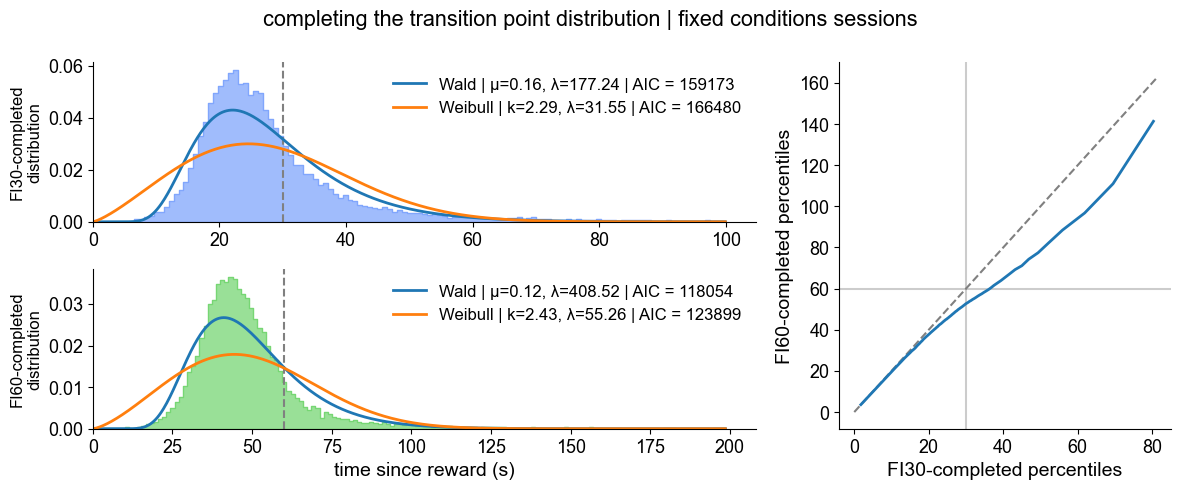

In [97]:
fig, axs = plt.subplots(2,2, tight_layout = True, figsize = (12,5), width_ratios=[2,1])
completed_cp30 = np.hstack([unidf.query('click == False and FI == 30').cp.values,
                        unidf.query('bool_cp == False and click == False and FI == 30 and count_lever == 1 and last_press < 100').last_press.values])

sns.histplot(completed_cp30, ax = axs[0,0], stat = 'density', element='step', color = color_FI_blocks[1])
axs[0,0].axvline(30, color = 'grey', ls = '--')

completed_cp60 = np.hstack([unidf.query('click == False and FI == 60').cp.values,
                        unidf.query('bool_cp == False and click == False and FI == 60 and count_lever == 1 and last_press < 200').last_press.values])
sns.histplot(completed_cp60, ax = axs[1,0], stat = 'density', element='step', color = color_FI_blocks[2])
axs[1,0].axvline(60, color = 'grey', ls = '--')

[axs[ii,0].set_xlim(0) for ii in range(2)]


## FI30

x = np.asarray(completed_cp30, float)
x = x[np.isfinite(x) & (x > 0)]
x.sort()

wald_fit = fit_shifted_invgauss(x)
weibull_fit = fit_shifted_weibull(x)


# wald
t = np.linspace(0, x.max(), 600)
mu, delta, lam = wald_fit[1]["mu"], wald_fit[1]["delta"], wald_fit[1]["lam"]
pdf = stats.invgauss.pdf(t, mu, loc=delta, scale=lam)
aic = 2*3 + 2*wald_fit[-1]
label = f"Wald | μ={mu:.2f}, λ={lam:.2f} | AIC = {aic:.0f}"
axs[0,0].plot(t, pdf, lw=2, label=label)

# weibull
k, delta, lam = weibull_fit[1]["k"], weibull_fit[1]["delta"], weibull_fit[1]["lam"]
pdf = stats.weibull_min.pdf(t, k, loc=delta, scale=lam)
aic = 2*3 + 2*weibull_fit[-1]
label = f"Weibull | k={k:.2f}, λ={lam:.2f} | AIC = {aic:.0f}"
axs[0,0].plot(t, pdf, lw=2, label=label)




## FI60

x = np.asarray(completed_cp60, float)
x = x[np.isfinite(x) & (x > 0)]
x.sort()

wald_fit = fit_shifted_invgauss(x)
weibull_fit = fit_shifted_weibull(x)


# wald
t = np.linspace(0, x.max(), 600)
mu, delta, lam = wald_fit[1]["mu"], wald_fit[1]["delta"], wald_fit[1]["lam"]
pdf = stats.invgauss.pdf(t, mu, loc=delta, scale=lam)
aic = 2*3 + 2*wald_fit[-1]
label = f"Wald | μ={mu:.2f}, λ={lam:.2f} | AIC = {aic:.0f}"
axs[1,0].plot(t, pdf, lw=2, label=label)

# weibull
k, delta, lam = weibull_fit[1]["k"], weibull_fit[1]["delta"], weibull_fit[1]["lam"]
pdf = stats.weibull_min.pdf(t, k, loc=delta, scale=lam)
aic = 2*3 + 2*weibull_fit[-1]
label = f"Weibull | k={k:.2f}, λ={lam:.2f} | AIC = {aic:.0f}"
axs[1,0].plot(t, pdf, lw=2, label=label)


axs[0,0].set_ylabel('FI30-completed\ndistribution', fontsize = 12)
axs[1,0].set_ylabel('FI60-completed\ndistribution', fontsize = 12)

[axs[ii,0].legend(frameon = False, fontsize = 12) for ii in range(2)]

axs[1,0].set_xlabel("time since reward (s)")




for ax in [axs[0, 1], axs[1, 1]]:
    fig.delaxes(ax)

# Now add the new big axis in that space
#from matplotlib.gridspec import GridSpec

gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])
ax_big = fig.add_subplot(gs[:, 1]) 

ax_big.axvline(30, color = 'grey', alpha = .4)
ax_big.axhline(60, color = 'grey', alpha = .4)
ax_big.plot([0,81],[0,162], color = 'grey', ls = '--')

ax_big.plot(np.nanquantile(completed_cp30, np.arange(0,1,.01)),
         np.nanquantile(completed_cp60, np.arange(0,1,.01)), lw = 2)
ax_big.set_xlabel('FI30-completed percentiles')
ax_big.set_ylabel('FI60-completed percentiles')


figtitle = f'completing the transition point distribution | fixed conditions sessions'
fig.suptitle(figtitle)
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.png')
#fig.savefig(fr'{fig_path}\{figtitle.replace('|', '_')}.pdf')


Model comparison (lower AIC is better):
invgauss  AIC=118054.2  NLL=59024.1  params={'mu': np.float64(0.12054415885368537), 'delta': 0, 'lam': np.float64(408.51663771200583)}
weibull   AIC=123899.1  NLL=61946.5  params={'k': np.float64(2.431443492583809), 'delta': 0, 'lam': np.float64(55.26496338475941)}


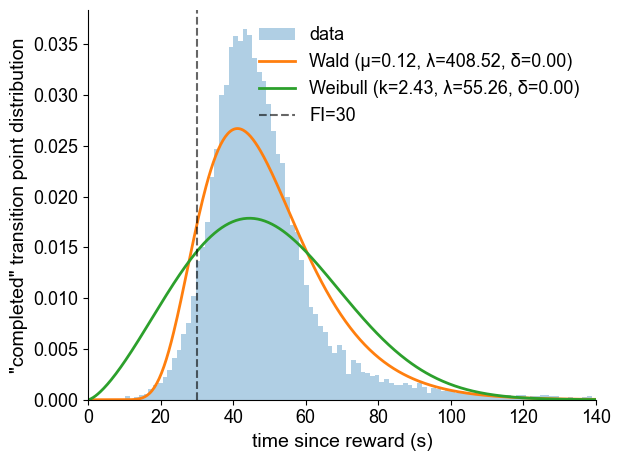

In [98]:
x = np.asarray(completed_cp60, float)
x = x[np.isfinite(x) & (x > 0)]
x.sort()


wald_fit = fit_shifted_invgauss(x)
weibull_fit = fit_shifted_weibull(x)

fits = [wald_fit, weibull_fit]
# AIC = 2k + 2*NLL  (k = # free params)
k_params = {"invgauss":3, "weibull":3}
results = []
for name, params, nll in fits:
    aic = 2*k_params[name] + 2*nll
    results.append((aic, name, params, nll))
results.sort()

best_aic, best_name, best_params, best_nll = results[0]
print("Model comparison (lower AIC is better):")
for aic, name, params, nll in results:
    print(f"{name:8s}  AIC={aic:.1f}  NLL={nll:.1f}  params={params}")

# Plot histogram + fits
bins = "auto"
plt.hist(x, bins=bins, density=True, alpha=0.35, label="data")

# wald
t = np.linspace(0, x.max(), 600)
mu, delta, lam = wald_fit[1]["mu"], wald_fit[1]["delta"], wald_fit[1]["lam"]
pdf = stats.invgauss.pdf(t, mu, loc=delta, scale=lam)
label = f"Wald (μ={mu:.2f}, λ={lam:.2f}, δ={delta:.2f})"
plt.plot(t, pdf, lw=2, label=label)

# weibull
k, delta, lam = weibull_fit[1]["k"], weibull_fit[1]["delta"], weibull_fit[1]["lam"]
pdf = stats.weibull_min.pdf(t, k, loc=delta, scale=lam)
label = f"Weibull (k={k:.2f}, λ={lam:.2f}, δ={delta:.2f})"
plt.plot(t, pdf, lw=2, label=label)

plt.axvline(30, color="k", ls="--", alpha=0.6, label="FI=30")
plt.ylabel('"completed" transition point distribution')
plt.xlabel("time since reward (s)")
plt.xlim(0,140)
plt.legend(frameon = False)
plt.tight_layout()
plt.show()


In [99]:
def cv(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x) & (x > 0)]
    return np.std(x, ddof=1) / np.mean(x)

def cv_bootstrap(x, B=5000, rng=None):
    rng = np.random.default_rng(rng)
    x = np.asarray(x, float)
    n = len(x)
    boots = [cv(x[rng.integers(0, n, n)]) for _ in range(B)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return cv(x), (lo, hi)

In [100]:
cv_bootstrap(completed_cp30)

(np.float64(0.4487711167854685),
 (np.float64(0.44156092102633554), np.float64(0.45595002753131386)))

In [101]:
cv_bootstrap(completed_cp60)

(np.float64(0.4044072817101898),
 (np.float64(0.39271213234864566), np.float64(0.4157257599673143)))

In [102]:
(np.nanstd(completed_cp30)/np.nanmean(completed_cp30))

np.float64(0.44876066018578664)

In [103]:
(np.nanstd(completed_cp60)/np.nanmean(completed_cp60))

np.float64(0.4043930025483574)

## Block analysis

This is new relative to the thesis, and the idea would be to 

and then there was photometry (thesis nb)